## 1. Introdução ao dataset

O presente estudo realiza uma análise exploratória do conjunto de dados "Air Quality UCI". Este dataset é de grande relevância para a área de ciências ambientais e aprendizado de máquina, pois contém registros detalhados da qualidade do ar de uma cidade metropolitana italiana, coletados entre março de 2004 e fevereiro de 2005.

Os dados foram capturados por um dispositivo multisensor que media, em intervalos horários, a concentração de diversos poluentes atmosféricos, como monóxido de carbono (CO), benzeno (C6H6) e óxidos de nitrogênio (NOx), além de registrar condições meteorológicas como temperatura e umidade.

A análise deste conjunto de dados visa identificar padrões, distribuições e correlações entre as variáveis, fornecendo insights valiosos sobre a dinâmica da poluição do ar em um ambiente urbano. O entendimento dessas características é o primeiro passo para a construção de modelos preditivos e para a avaliação do impacto ambiental na saúde pública.

## 2. Descrição dataset.

#### 2.1 Importando bibliotecas.

In [37]:
import os
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
from scipy import stats

#### 2.2 Configurações e padronização.

In [38]:
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
%matplotlib inline

# Tema e parâmetros globais
palette_theme = "ch:start=.2,rot=-.3"
sns.set_theme(style="darkgrid")

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "figure.figsize": (20, 6),
    "axes.titlesize": 18,
    "axes.labelsize": 9,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "figure.autolayout": True,
    "figure.titleweight": "bold",  
    "axes.titlepad": 20
})

# Diretório de figuras
PATH_FIG = "./figures"
os.makedirs(PATH_FIG, exist_ok=True)

# Paleta única do projeto
palette = sns.color_palette(palette_theme, n_colors=6)

# Função simples de salvar figura (uma linha só, usada muitas vezes)
savefig = lambda name: plt.savefig(os.path.join(PATH_FIG, f"{name}.png"), bbox_inches="tight")

#### 2.3 Carregando dataset.

In [39]:
# Caminho do CSV (ajuste se necessário)
data_path = "../database/air_quality_uci.csv"

# Leitura
air_quality = pd.read_csv(
    data_path,
    sep=";",
    decimal=",",
    na_values=-200,
    parse_dates={"datetime": ["Date", "Time"]},
    date_format="%d/%m/%Y %H.%M.%S",
    index_col="datetime"
)

# Garantia do tipo datetime
air_quality.index = pd.to_datetime(air_quality.index, format="%d/%m/%Y %H.%M.%S", errors="coerce")

# Remoção de colunas vazias finais (presentes no dataset original)
air_quality = air_quality.iloc[:, :-2]

# Exibir 5 linhas aleatórias para verificar se foi carregado corretamente
print(f"Dataset shape: {air_quality.shape}")
air_quality.sample(5)

Dataset shape: (9471, 13)


,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
datetime,,,,,,,,,,,,,
2004-09-24 16:00:00,2.7,1222.0,NaN,14.5,1133.0,282.0,624.0,96.0,1698.0,1195.0,24.9,49.2,1.5251
2004-03-28 16:00:00,1.3,987.0,116.0,4.3,727.0,73.0,1213.0,70.0,1244.0,502.0,18.2,28.3,0.5848
2005-02-15 23:00:00,2.1,1145.0,NaN,9.2,946.0,366.0,699.0,182.0,1015.0,1409.0,6.6,37.5,0.3664
2004-03-25 10:00:00,2.3,1133.0,300.0,8.8,933.0,133.0,969.0,99.0,1552.0,923.0,9.7,69.7,0.8389
2004-06-11 06:00:00,1.0,912.0,NaN,7.0,858.0,92.0,923.0,69.0,1608.0,894.0,19.8,50.4,1.1525


#### 2.5 Listagem de variáveis.
Lista variáveis, tipos de dados e contagem de valores não nulos.

In [40]:
print("Dataset Information:")
print("=" * 80)
air_quality.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 9471 entries, 2004-03-10 18:00:00 to NaT
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   CO(GT)         7674 non-null   float64
 1   PT08.S1(CO)    8991 non-null   float64
 2   NMHC(GT)       914 non-null    float64
 3   C6H6(GT)       8991 non-null   float64
 4   PT08.S2(NMHC)  8991 non-null   float64
 5   NOx(GT)        7718 non-null   float64
 6   PT08.S3(NOx)   8991 non-null   float64
 7   NO2(GT)        7715 non-null   float64
 8   PT08.S4(NO2)   8991 non-null   float64
 9   PT08.S5(O3)    8991 non-null   float64
 10  T              8991 non-null   float64
 11  RH             8991 non-null   float64
 12  AH             8991 non-null   float64
dtypes: float64(13)
memory usage: 1.0 MB


#### 2.6 Contagem de valores nulos por variáveis
Contagem detalhada de missing values.

In [41]:
print("\nMissing Values and Percentage (%):")
missing = air_quality.isnull().sum()
percent = (missing / len(air_quality) * 100).round(2)
missing_df = pd.DataFrame({"Missing Values": missing, "Percentage (%)": percent})
display(missing_df.sort_values("Missing Values", ascending=False))
print(f"\nTotal missing values: {missing.sum()}")


Missing Values and Percentage (%):


,Missing Values,Percentage (%)
NMHC(GT),8557,90.35
CO(GT),1797,18.97
NO2(GT),1756,18.54
NOx(GT),1753,18.51
PT08.S1(CO),480,5.07
PT08.S2(NMHC),480,5.07
C6H6(GT),480,5.07
PT08.S3(NOx),480,5.07
PT08.S4(NO2),480,5.07
PT08.S5(O3),480,5.07



Total missing values: 18183


#### 2.7 Apagar linhas duplicadas

In [42]:
dups = air_quality.duplicated().sum()
display(air_quality[air_quality.duplicated()].sample(5))
air_quality = air_quality.drop_duplicates()
print(f"Duplicatas removidas: {dups}")

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
datetime,,,,,,,,,,,,,
NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2004-05-26 02:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Duplicatas removidas: 145


# 3. Estátisticas univariadas incondicionais

#### 3.1 Calculo da media
A média, ou valor médio, é a medida de tendência central mais comum. No contexto do nosso dataset, ela nos dará um valor "típico" para cada sensor e medição ao longo de todo o período de coleta.

In [43]:
# Cálculo da média para cada variável numérica
print("Média para cada variável:")
air_quality.mean(numeric_only=True)

Média para cada variável:


CO(GT)              2.152926
PT08.S1(CO)      1099.833166
NMHC(GT)          218.811816
C6H6(GT)           10.083105
PT08.S2(NMHC)     939.153376
NOx(GT)           246.896735
PT08.S3(NOx)      835.493605
NO2(GT)           113.091251
PT08.S4(NO2)     1456.264598
PT08.S5(O3)      1022.906128
T                  18.317829
RH                 49.234201
AH                  1.025530
dtype: float64

#### 3.2 Calculo do desvio padrao
O desvio padrão nos diz o quão espalhados ou variáveis os dados são em torno dessa média. Um desvio padrão baixo significa que a maioria dos valores está muito próxima da média. Os dados são consistentes e previsíveis. Um desvio padrão alto significa que os valores estão muito espalhados. Há uma grande variação nas medições, com muitos valores longe da média. 
Para o nosso dataset, o desvio padrão vai nos ajudar a entender a volatilidade de cada poluente e condição climática.

In [44]:
#Cálculo do desvio padrão para cada variável numérica
print("\nDesvio padrão para cada variável:")
air_quality.std(numeric_only=True)


Desvio padrão para cada variável:


CO(GT)             1.453265
PT08.S1(CO)      217.080037
NMHC(GT)         204.459921
C6H6(GT)           7.449820
PT08.S2(NMHC)    266.831429
NOx(GT)          212.979168
PT08.S3(NOx)     256.817320
NO2(GT)           48.370108
PT08.S4(NO2)     346.206794
PT08.S5(O3)      398.484288
T                  8.832116
RH                17.316892
AH                 0.403813
dtype: float64

#### 3.3 Describe
Resumo estatístico completo, contagem, média, desvio padrão, quartis e min/max

In [45]:
air_quality.describe()

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
count,7673.000000,8991.000000,914.000000,8991.000000,8991.000000,7718.000000,8991.000000,7715.000000,8991.000000,8991.000000,8991.000000,8991.000000,8991.000000
mean,2.152926,1099.833166,218.811816,10.083105,939.153376,246.896735,835.493605,113.091251,1456.264598,1022.906128,18.317829,49.234201,1.025530
std,1.453265,217.080037,204.459921,7.449820,266.831429,212.979168,256.817320,48.370108,346.206794,398.484288,8.832116,17.316892,0.403813
min,0.100000,647.000000,7.000000,0.100000,383.000000,2.000000,322.000000,2.000000,551.000000,221.000000,-1.900000,9.200000,0.184700
25%,1.100000,937.000000,67.000000,4.400000,734.500000,98.000000,658.000000,78.000000,1227.000000,731.500000,11.800000,35.800000,0.736800
50%,1.800000,1063.000000,150.000000,8.200000,909.000000,180.000000,806.000000,109.000000,1463.000000,963.000000,17.800000,49.600000,0.995400
75%,2.900000,1231.000000,297.000000,14.000000,1116.000000,326.000000,969.500000,142.000000,1674.000000,1273.500000,24.400000,62.500000,1.313700
max,11.900000,2040.000000,1189.000000,63.700000,2214.000000,1479.000000,2683.000000,340.000000,2775.000000,2523.000000,44.600000,88.700000,2.231000


#### 3.4 Calculo de skewness (Assimetria)
Enquanto a média e o desvio padrão nos dão informações sobre o centro e a dispersão, a skewness nos diz sobre a forma da distribuição.
- Skewness ≈ 0: A distribuição é quase simétrica. Os dados se espalham de maneira uniforme em ambos os lados da média. A curva parece um sino (distribuição normal).
- Skewness > 0: A distribuição tem uma "cauda" mais longa à direita. Isso significa que, embora a maioria dos valores esteja concentrada à esquerda, existem alguns valores extremamente altos que "puxam" a média para a direita.
- Skewness < 0: A distribuição tem uma "cauda" mais longa à esquerda. A maioria dos valores está concentrada à direita, mas alguns valores extremamente baixos "puxam" a média para a esquerda.
No nosso caso, a Skewness vai nos dizer, por exemplo, se os picos de poluição são mais comuns do que períodos de ar excepcionalmente limpo.

In [46]:
# Calcula a skewness para todas as colunas numéricas
print("Assimetria (Skewness) para cada variável:")
air_quality.skew(numeric_only=True)

Assimetria (Skewness) para cada variável:


CO(GT)           1.369637
PT08.S1(CO)      0.755907
NMHC(GT)         1.557017
C6H6(GT)         1.361532
PT08.S2(NMHC)    0.561566
NOx(GT)          1.715781
PT08.S3(NOx)     1.101729
NO2(GT)          0.621714
PT08.S4(NO2)     0.205389
PT08.S5(O3)      0.627864
T                0.309357
RH              -0.037928
AH               0.251388
dtype: float64

#### 3.5 Plotagem dos gráficos
Nesta seção, visualizamos as distribuições que acabamos de medir.

##### 3.5.1 Histogramas

In [47]:
numeric_cols = air_quality.select_dtypes(include=np.number).columns
air_quality_numeric = air_quality[numeric_cols]

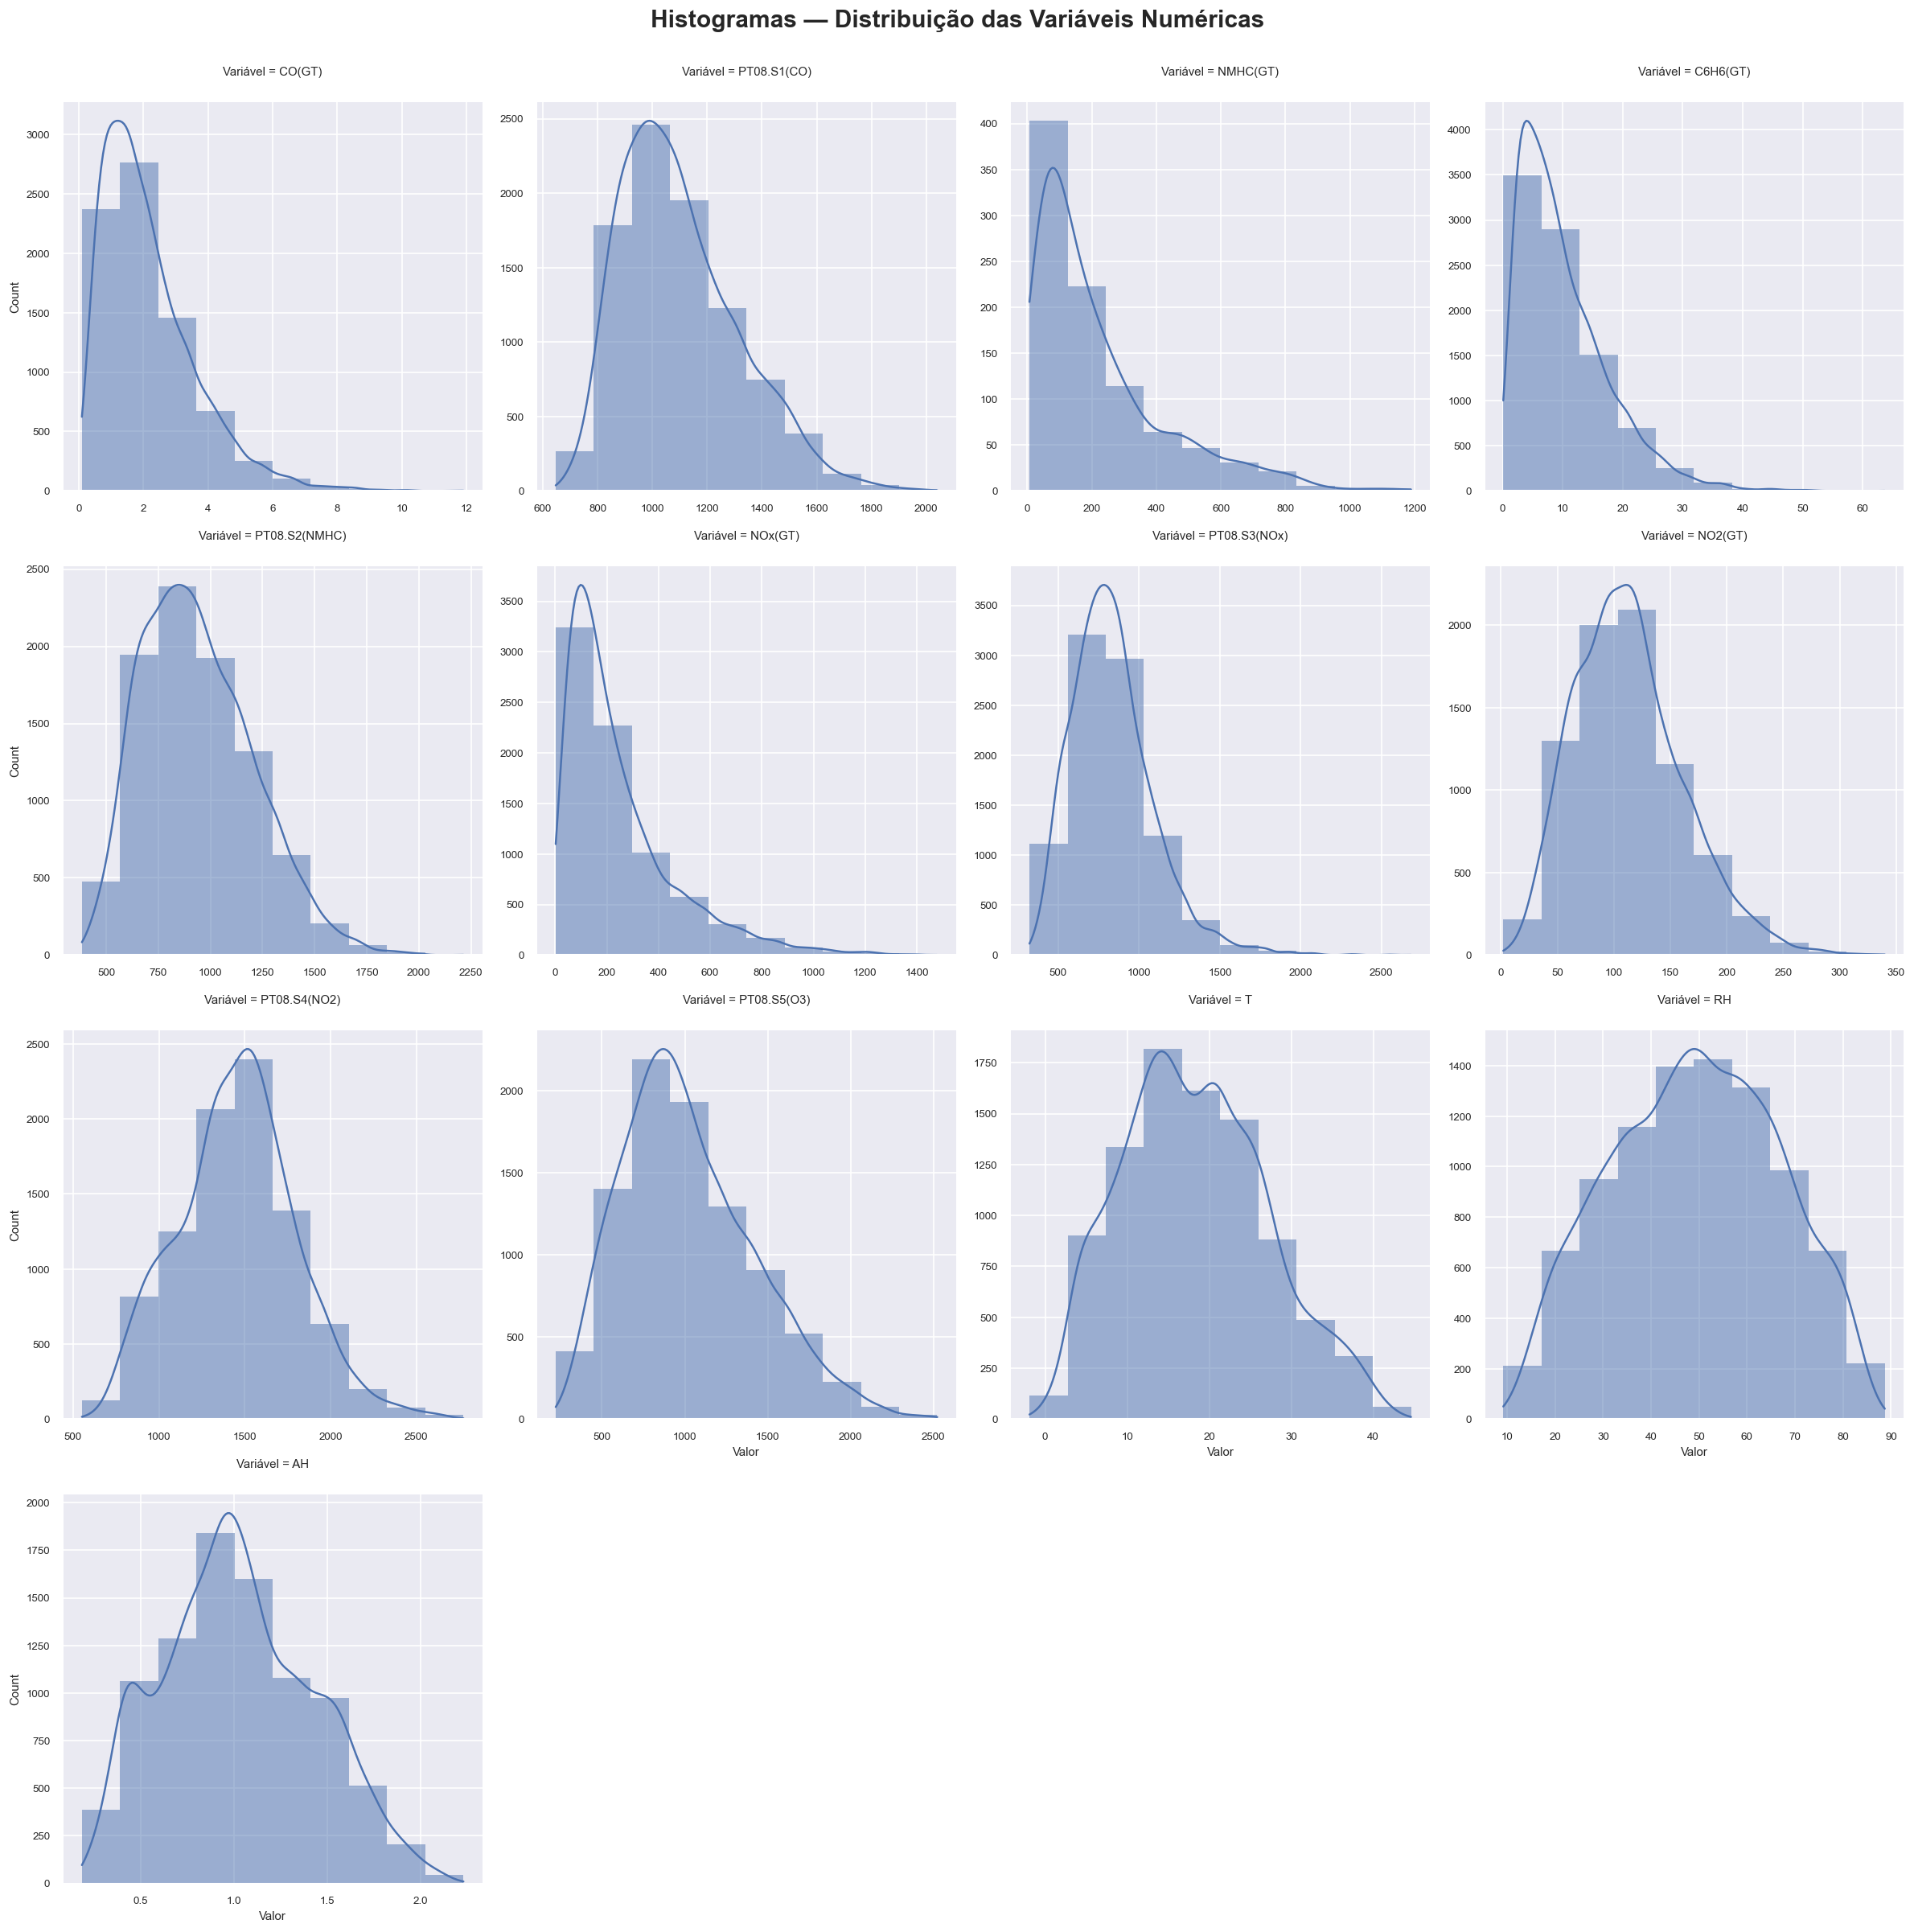

In [48]:
hist = sns.displot(
    air_quality_numeric.melt(var_name="Variável", value_name="Valor"),
    x="Valor",
    col="Variável",
    col_wrap=4,
    kde=True,
    bins=10,
    edgecolor="white",
    common_bins=False,
    common_norm=False,
    facet_kws=dict(margin_titles=True, sharex=False, sharey=False),
)
hist.figure.suptitle("Histogramas — Distribuição das Variáveis Numéricas", fontsize=18, weight="bold", y=1)
plt.tight_layout()
savefig("histograms_univariate")
plt.show()

##### 3.5.2 Box Plots

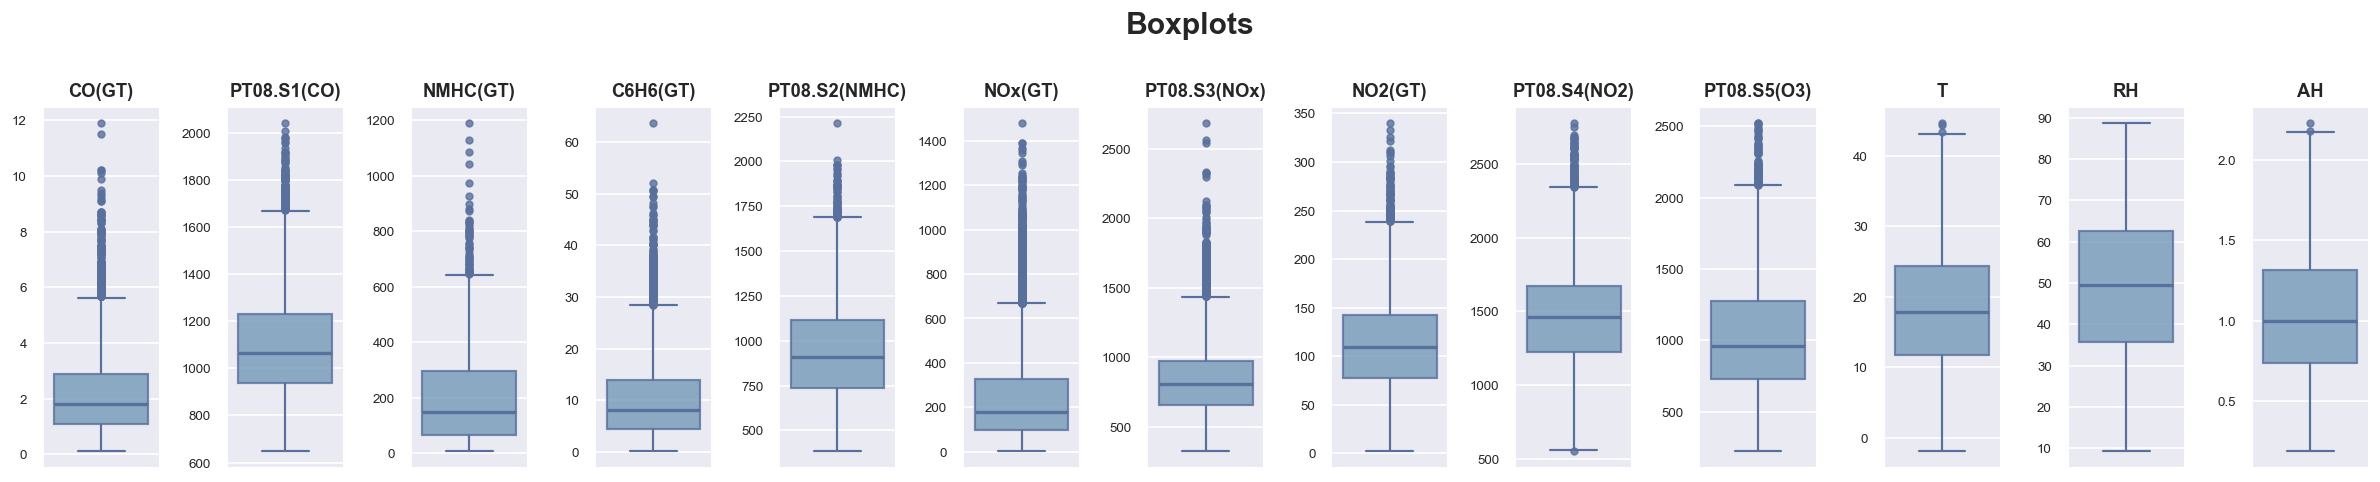

In [49]:
# Tema + paleta
fill, edge, outlier = palette[2], palette[3], palette[3]

# Grid automático
n_cols = 13
n_rows = int(np.ceil(len(numeric_cols) / n_cols))
fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(20, 4 * n_rows), dpi=120)
axes = axes.flatten()

for col, ax in zip(numeric_cols, axes):
    sns.boxplot(
        y=air_quality[col],
        ax=ax,
        linewidth=1.3,
        fliersize=3,
        boxprops=dict(facecolor=fill, edgecolor=edge, alpha=0.8),
        medianprops=dict(color=edge, linewidth=2),
        whiskerprops=dict(color=edge),
        capprops=dict(color=edge),
        flierprops=dict(
            marker="o",
            markerfacecolor=outlier,
            markeredgecolor=outlier,
            alpha=0.8,
            markersize=4,
        ),
    )
    ax.set_title(col, fontsize=11, fontweight="bold", pad=6)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis='y', labelsize=8)
fig.suptitle("Boxplots", y=1, fontsize=18, weight="bold")
plt.tight_layout()
savefig("boxplot")
plt.show()

##### 3.5.3 Violin Plots

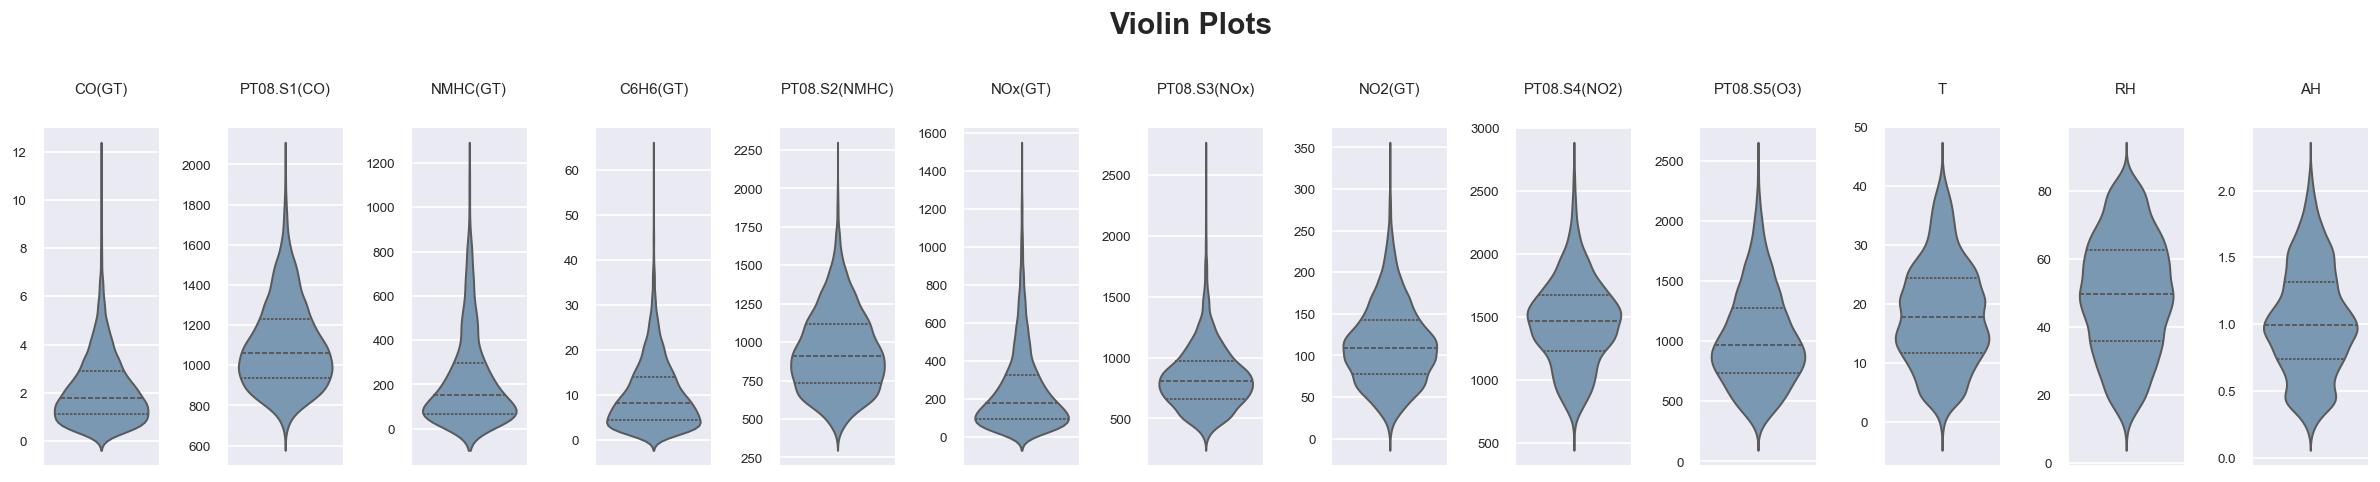

In [50]:
# Layout automático
n_cols = 13
n_rows = int(np.ceil(len(numeric_cols) / n_cols))
fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(20, 4 * n_rows), dpi=120)
axes = axes.flatten()

for col, ax in zip(numeric_cols, axes):
    sns.violinplot(
        y=air_quality[col],
        ax=ax,
        inner="quartile",
        linewidth=1.2,
        color=fill,
        saturation=0.8,
    )
    ax.set_title(col, fontsize=9)
    ax.set_xlabel("")
    ax.set_ylabel("")
for ax in axes[len(numeric_cols):]:
    ax.set_visible(False)

fig.suptitle("Violin Plots", y=1, fontsize=18, weight="bold")
plt.tight_layout()
savefig("violinplot")
plt.show()

##### 3.5.4 Gráfico de resumo (Série temporal + Histograma)

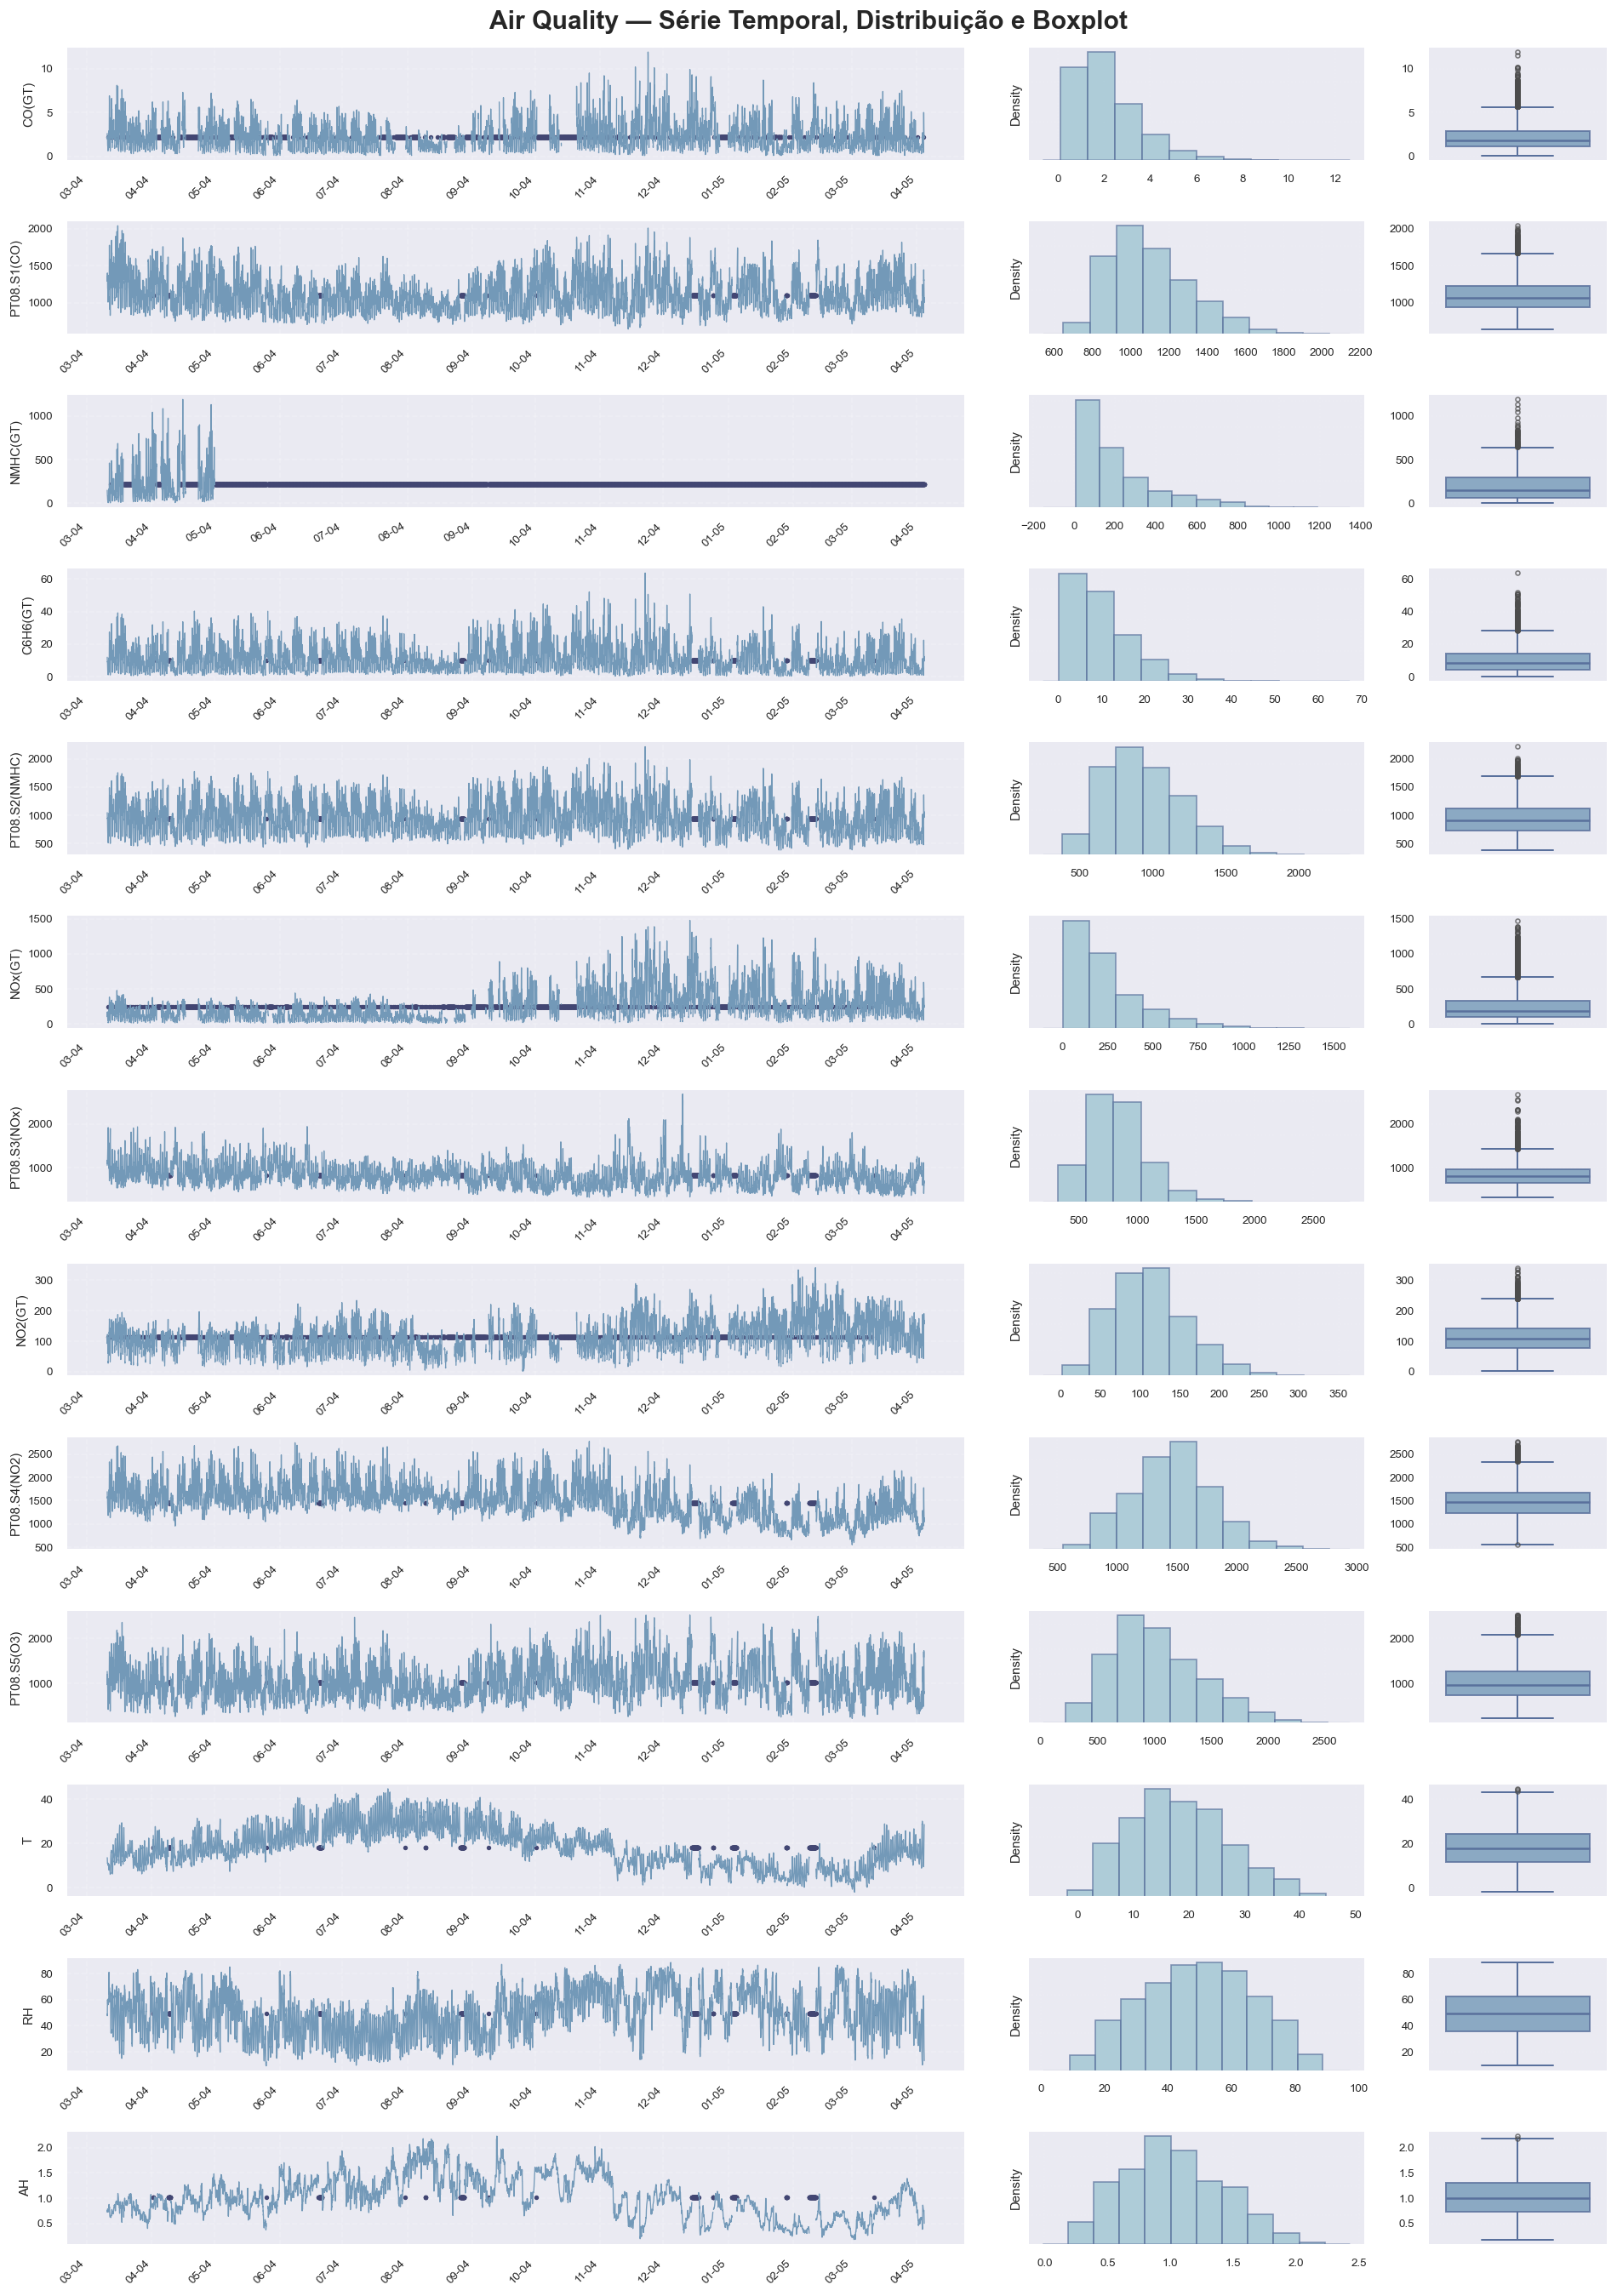

In [51]:
import matplotlib.dates as mdates

cols = air_quality.select_dtypes("number").columns

# 3 colunas: série temporal, histograma e boxplot
fig, axes = plt.subplots(
    len(cols), 3,
    figsize=(16, len(cols) * 1.8),
    gridspec_kw={"width_ratios": [4, 1.5, 0.8]}
)
fig.suptitle("Air Quality — Série Temporal, Distribuição e Boxplot", fontsize=18, weight="bold", y=0.96)

for i, col in enumerate(cols):
    ax_ts, ax_hist, ax_box = axes[i]

    # ===== Série Temporal =====
    air_quality[col].plot(ax=ax_ts, lw=0.8, color=palette[2])
    ax_ts.set_ylabel(col)
    ax_ts.set_xlabel("")
    ax_ts.grid(True, alpha=0.2, linestyle="--")

    # Formato do eixo X (MM-AA)
    ax_ts.xaxis.set_major_formatter(mdates.DateFormatter("%m-%y"))
    ax_ts.xaxis.set_major_locator(mdates.MonthLocator())
    plt.setp(ax_ts.get_xticklabels(), rotation=45, ha="right", fontsize=8)

    # Valores ausentes
    na_mask = air_quality[col].isna()
    ax_ts.scatter(air_quality.index[na_mask], [air_quality[col].mean()] * na_mask.sum(), color=palette[4], s=5)

    # ===== Histograma =====
    data = air_quality[col].dropna()
    ax_hist.hist(data, bins=10, color=palette[1], alpha=0.7, edgecolor=palette[3])
    sns.kdeplot(data=data, ax=ax_hist, color=palette[3], lw=1.3)
    ax_hist.tick_params(axis="y", labelleft=False)
    ax_hist.set_xlabel("")
    ax_hist.grid(True, alpha=0.1, linestyle=":")

    # ===== Boxplot =====
    sns.boxplot(
        y=data,
        ax=ax_box,
        linewidth=1.2,
        fliersize=3,
        boxprops=dict(facecolor=palette[2], edgecolor=palette[3], alpha=0.8),
        medianprops=dict(color=palette[3], linewidth=1.5),
        whiskerprops=dict(color=palette[3]),
        capprops=dict(color=palette[3]),
        flierprops=dict(marker="o", color=palette[3], markersize=3, alpha=0.7),
    )
    ax_box.set_xlabel("")
    ax_box.set_ylabel("")
    ax_box.set_title("")
    ax_box.tick_params(axis="y", labelsize=8)
    ax_box.grid(True, alpha=0.1, linestyle=":")

plt.tight_layout(rect=[0, 0, 1, 0.97])
savefig("air_quality_summary_full")
plt.show()


In [52]:
air_quality

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
datetime,,,,,,,,,,,,,
2004-03-10 18:00:00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
2004-03-10 19:00:00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2004-03-10 20:00:00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
2004-03-10 21:00:00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
2004-03-10 22:00:00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2005-04-04 10:00:00,3.1,1314.0,NaN,13.5,1101.0,472.0,539.0,190.0,1374.0,1729.0,21.9,29.3,0.7568
2005-04-04 11:00:00,2.4,1163.0,NaN,11.4,1027.0,353.0,604.0,179.0,1264.0,1269.0,24.3,23.7,0.7119
2005-04-04 12:00:00,2.4,1142.0,NaN,12.4,1063.0,293.0,603.0,175.0,1241.0,1092.0,26.9,18.3,0.6406


#### 3.6 Criação das Classes

#### Definição dos poluentes para o Índice
Selecionamos os 4 principais poluentes de referência (GT) para construir nosso índice. Decidimos que o NMHC(GT) não era uma variável confiável devido aos seus >90% de dados faltantes, por isso foi excluída desta análise.

In [53]:
pollutants = ["CO(GT)", "NOx(GT)", "NO2(GT)", "C6H6(GT)"]

#### Normalização Z-Score
Padronização dos poluentes selecionados. Nossos 4 poluentes têm escalas e unidades diferentes (mg/m³, ppb, etc.). A normalização Z-score os coloca em uma escala comum, permitindo que sejam combinados.

In [54]:
# Z-score normalization for CPI – Composite Pollution Index
air_quality = (
    air_quality
    .dropna(subset=pollutants)
    .assign(
        **{
            f"{p}_z": (air_quality[p] - air_quality[p].mean()) / air_quality[p].std()
            for p in pollutants
        }
    )
)

#### Índice de Poluição Composto (CPI)
Em vez de analisar cada poluente separadamente, criamos uma única métrica (pollution_index) que representa o "nível de poluição geral" naquele momento.

In [55]:
# Define pollution index as the mean of z-scores of selected pollutants
z_cols = [f"{p}_z" for p in pollutants]
air_quality["pollution_index"] = air_quality[z_cols].mean(axis=1)

##### Criação das Classes de Poluição (L)
Agora temos L = 3. Essas classes são a base para toda a análise condicional.

In [56]:
# Categorize pollution index into Low, Moderate, High using quantiles
air_quality["pollution_class"] = pd.qcut(
    air_quality["pollution_index"], q=3, labels=["Low", "Moderate", "High"]
)

In [57]:
# Display the first few rows of the DataFrame with the new columns
air_quality["pollution_class"].value_counts()

pollution_class
Low         2314
High        2314
Moderate    2313
Name: count, dtype: int64

##### Engenharia de Atributos Temporais
Extração de características do índice de tempo. Isso nos permite analisar padrões sazonais, semanais e diários.

In [58]:
# Create an ordered categorical month column
air_quality["month"] = pd.Categorical(
    air_quality.index.month_name().str[:3].str.lower(),
    categories=["jan","feb","mar","apr","may","jun","jul","aug","sep","oct","nov","dec"],
    ordered=True
)

In [59]:
# Create an ordered categorical weekday column
air_quality["weekday"] = pd.Categorical(
    air_quality.index.day_name().str[:3].str.lower(),
    categories=["mon","tue","wed","thu","fri","sat","sun"],
    ordered=True
)

In [60]:
# Create a categorical day period column based on hour of the day
hours = air_quality.index.hour
air_quality["day_period"] = pd.cut(hours, bins=[0, 6, 12, 18, 24],labels=["ngt", "mng", "aft", "eve"], right=False, include_lowest=True)

In [61]:
air_quality

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,CO(GT)_z,NOx(GT)_z,NO2(GT)_z,C6H6(GT)_z,pollution_index,pollution_class,month,weekday,day_period
datetime,,,,,,,,,,,,,,,,,,,,,,
2004-03-10 18:00:00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,0.307634,-0.379834,-0.001887,0.243884,0.042450,Moderate,mar,wed,eve
2004-03-10 19:00:00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,-0.105229,-0.675638,-0.436039,-0.091694,-0.327150,Moderate,mar,wed,eve
2004-03-10 20:00:00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,0.032392,-0.544169,0.018787,-0.145387,-0.159594,Moderate,mar,wed,eve
2004-03-10 21:00:00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,0.032392,-0.351662,0.184179,-0.118540,-0.063408,Moderate,mar,wed,eve
2004-03-10 22:00:00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,-0.380472,-0.544169,0.060135,-0.480965,-0.336368,Moderate,mar,wed,eve
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2005-04-04 10:00:00,3.1,1314.0,NaN,13.5,1101.0,472.0,539.0,190.0,1374.0,1729.0,21.9,29.3,0.7568,0.651687,1.056926,1.590006,0.458655,0.939318,High,apr,mon,mng
2005-04-04 11:00:00,2.4,1163.0,NaN,11.4,1027.0,353.0,604.0,179.0,1264.0,1269.0,24.3,23.7,0.7119,0.170013,0.498186,1.362593,0.176769,0.551890,High,apr,mon,mng
2005-04-04 12:00:00,2.4,1142.0,NaN,12.4,1063.0,293.0,603.0,175.0,1241.0,1092.0,26.9,18.3,0.6406,0.170013,0.216468,1.279897,0.311000,0.494345,High,apr,mon,aft


# 4. Estátisticas univariadas condicionada por classes

##### 4.1 Análise Condicional por Classe de Poluição
Refizemos os histogramas, box plots e tabelas de estatísticas, mas agora agrupando os dados pelas nossas 3 classes ("Low", "Moderate", "High").

In [ ]:
# Cores do boxplot conforme padrão definido
fill, edge, outlier = palette[2], palette[3], palette[3]

predictors = ["PT08.S1(CO)", "PT08.S2(NMHC)", "PT08.S3(NOx)",
              "PT08.S4(NO2)", "PT08.S5(O3)", "T", "RH", "AH"]

# Define proporção: histograma ocupa 3x o espaço do boxplot
fig, axes = plt.subplots(
    nrows=len(predictors),
    ncols=2,
    figsize=(14, len(predictors) * 2),
    dpi=plt.rcParams["figure.dpi"],
    gridspec_kw={"width_ratios": [3, 1]}
)

for i, col in enumerate(predictors):
    # --- Histograma (mantém igual) ---
    sns.histplot(
        data=air_quality, x=col, hue="pollution_class",
        element="step", stat="density", common_norm=False,
        bins=30, ax=axes[i, 0]
    )
    axes[i, 0].set_title(f"{col} × pollution_class (Hist)", fontsize=9)
    axes[i, 0].set_xlabel(""); axes[i, 0].set_ylabel("")
    axes[i, 0].grid(True, alpha=0.3, linestyle="--")

    # --- Boxplot (cores ajustadas) ---
    sns.boxplot(
        data=air_quality,
        x="pollution_class", y=col, ax=axes[i, 1],
        linewidth=1.3, fliersize=3,
        boxprops=dict(facecolor=fill, edgecolor=edge, alpha=0.8),
        medianprops=dict(color=edge, linewidth=2),
        whiskerprops=dict(color=edge),
        capprops=dict(color=edge),
        flierprops=dict(
            marker="o",
            markerfacecolor=outlier,
            markeredgecolor=outlier,
            alpha=0.8,
            markersize=4
        ),
    )
    axes[i, 1].set_title(f"{col} × pollution_class (Box)", fontsize=9)
    axes[i, 1].set_xlabel(""); axes[i, 1].set_ylabel("")
    axes[i, 1].grid(True, alpha=0.2, linestyle=":")

plt.tight_layout()
savefig("pollution_class_boxplots")
plt.show()

# Estatísticas
stats_df = air_quality.groupby("pollution_class")[predictors].agg(["mean", "std", "skew"])
stats_df.columns = ["_".join(col) for col in stats_df.columns]
stats_df = stats_df.reset_index().round(4)
display(stats_df)


##### 4.2 Análise Condicional por Tempo
Repetimos a mesma análise, mas desta vez agrupando pelas classes temporais que criamos (month, weekday, day_period).


=== MONTH ===



,PT08.S1(CO)_mean,PT08.S1(CO)_std,PT08.S1(CO)_skew,PT08.S2(NMHC)_mean,PT08.S2(NMHC)_std,PT08.S2(NMHC)_skew,PT08.S3(NOx)_mean,PT08.S3(NOx)_std,PT08.S3(NOx)_skew,PT08.S4(NO2)_mean,PT08.S4(NO2)_std,PT08.S4(NO2)_skew,PT08.S5(O3)_mean,PT08.S5(O3)_std,PT08.S5(O3)_skew,T_mean,T_std,T_skew,RH_mean,RH_std,RH_skew,AH_mean,AH_std,AH_skew
month,,,,,,,,,,,,,,,,,,,,,,,,
jan,1137.4189,222.3181,0.4301,928.3750,272.4130,0.3734,752.5693,235.5101,0.6887,1185.1419,283.0958,0.3920,1149.8682,457.0144,0.1694,8.5360,3.8588,0.1712,56.4252,14.4162,-0.2983,0.6466,0.2304,0.1163
feb,1092.9519,195.4096,1.1318,851.7718,225.5236,0.6422,782.3512,206.1891,0.6587,1062.4902,217.2412,0.7722,1041.8271,440.5224,0.7073,7.2775,3.4897,0.4887,51.3850,17.1594,0.2739,0.5161,0.1494,0.6057
mar,1188.7642,217.8847,0.6391,923.5452,252.5353,0.5178,818.7633,270.2158,0.9007,1378.0642,326.0516,0.4012,1081.5325,394.8270,0.3572,13.9186,5.7056,-0.0633,50.0973,15.8165,-0.1385,0.7872,0.2432,-0.1623
apr,1153.4925,241.1658,0.5564,933.9007,279.1078,0.3885,913.5000,253.3580,0.9294,1521.8390,377.1095,0.1262,978.9775,418.4247,0.3137,16.8755,4.8193,0.6244,46.6247,16.0307,0.1399,0.8517,0.2052,0.4496
may,1101.4236,193.3665,0.6106,978.9965,226.3857,0.3648,911.1195,215.6039,0.6015,1628.2021,259.4266,0.7805,958.0088,323.0473,0.5617,20.9395,5.0564,0.5135,42.0838,16.5478,0.2442,0.9654,0.2093,-0.2434
jun,1038.5702,162.1684,0.2526,990.5860,240.4644,0.1676,871.7070,207.3498,1.0138,1742.6737,256.1283,0.7074,961.9789,316.2808,0.5341,27.1635,6.0347,0.4813,38.2875,13.5746,0.3636,1.2760,0.2046,0.0910
jul,1054.3009,154.4830,0.5539,980.9215,221.9427,0.3145,803.7850,161.7312,0.4454,1655.0318,224.6926,0.8757,1007.6262,359.5409,0.5612,29.4794,6.2497,0.3399,32.9576,12.9541,0.1682,1.2413,0.2551,0.3925
aug,982.3407,110.3097,0.1963,842.4265,142.9877,0.3155,833.1544,147.6127,0.5002,1589.9044,172.6962,0.3028,774.7819,222.2847,0.7594,29.9066,5.1744,0.2025,41.9365,14.5142,0.0232,1.6503,0.3054,-0.5273
sep,1090.3636,204.2441,0.4621,1032.6636,274.5190,0.3513,803.5364,217.1200,0.5987,1557.4955,294.5602,0.7660,1078.3159,357.6872,0.4755,23.7045,5.1785,0.2862,43.8755,14.0192,0.1339,1.2262,0.2801,0.0008


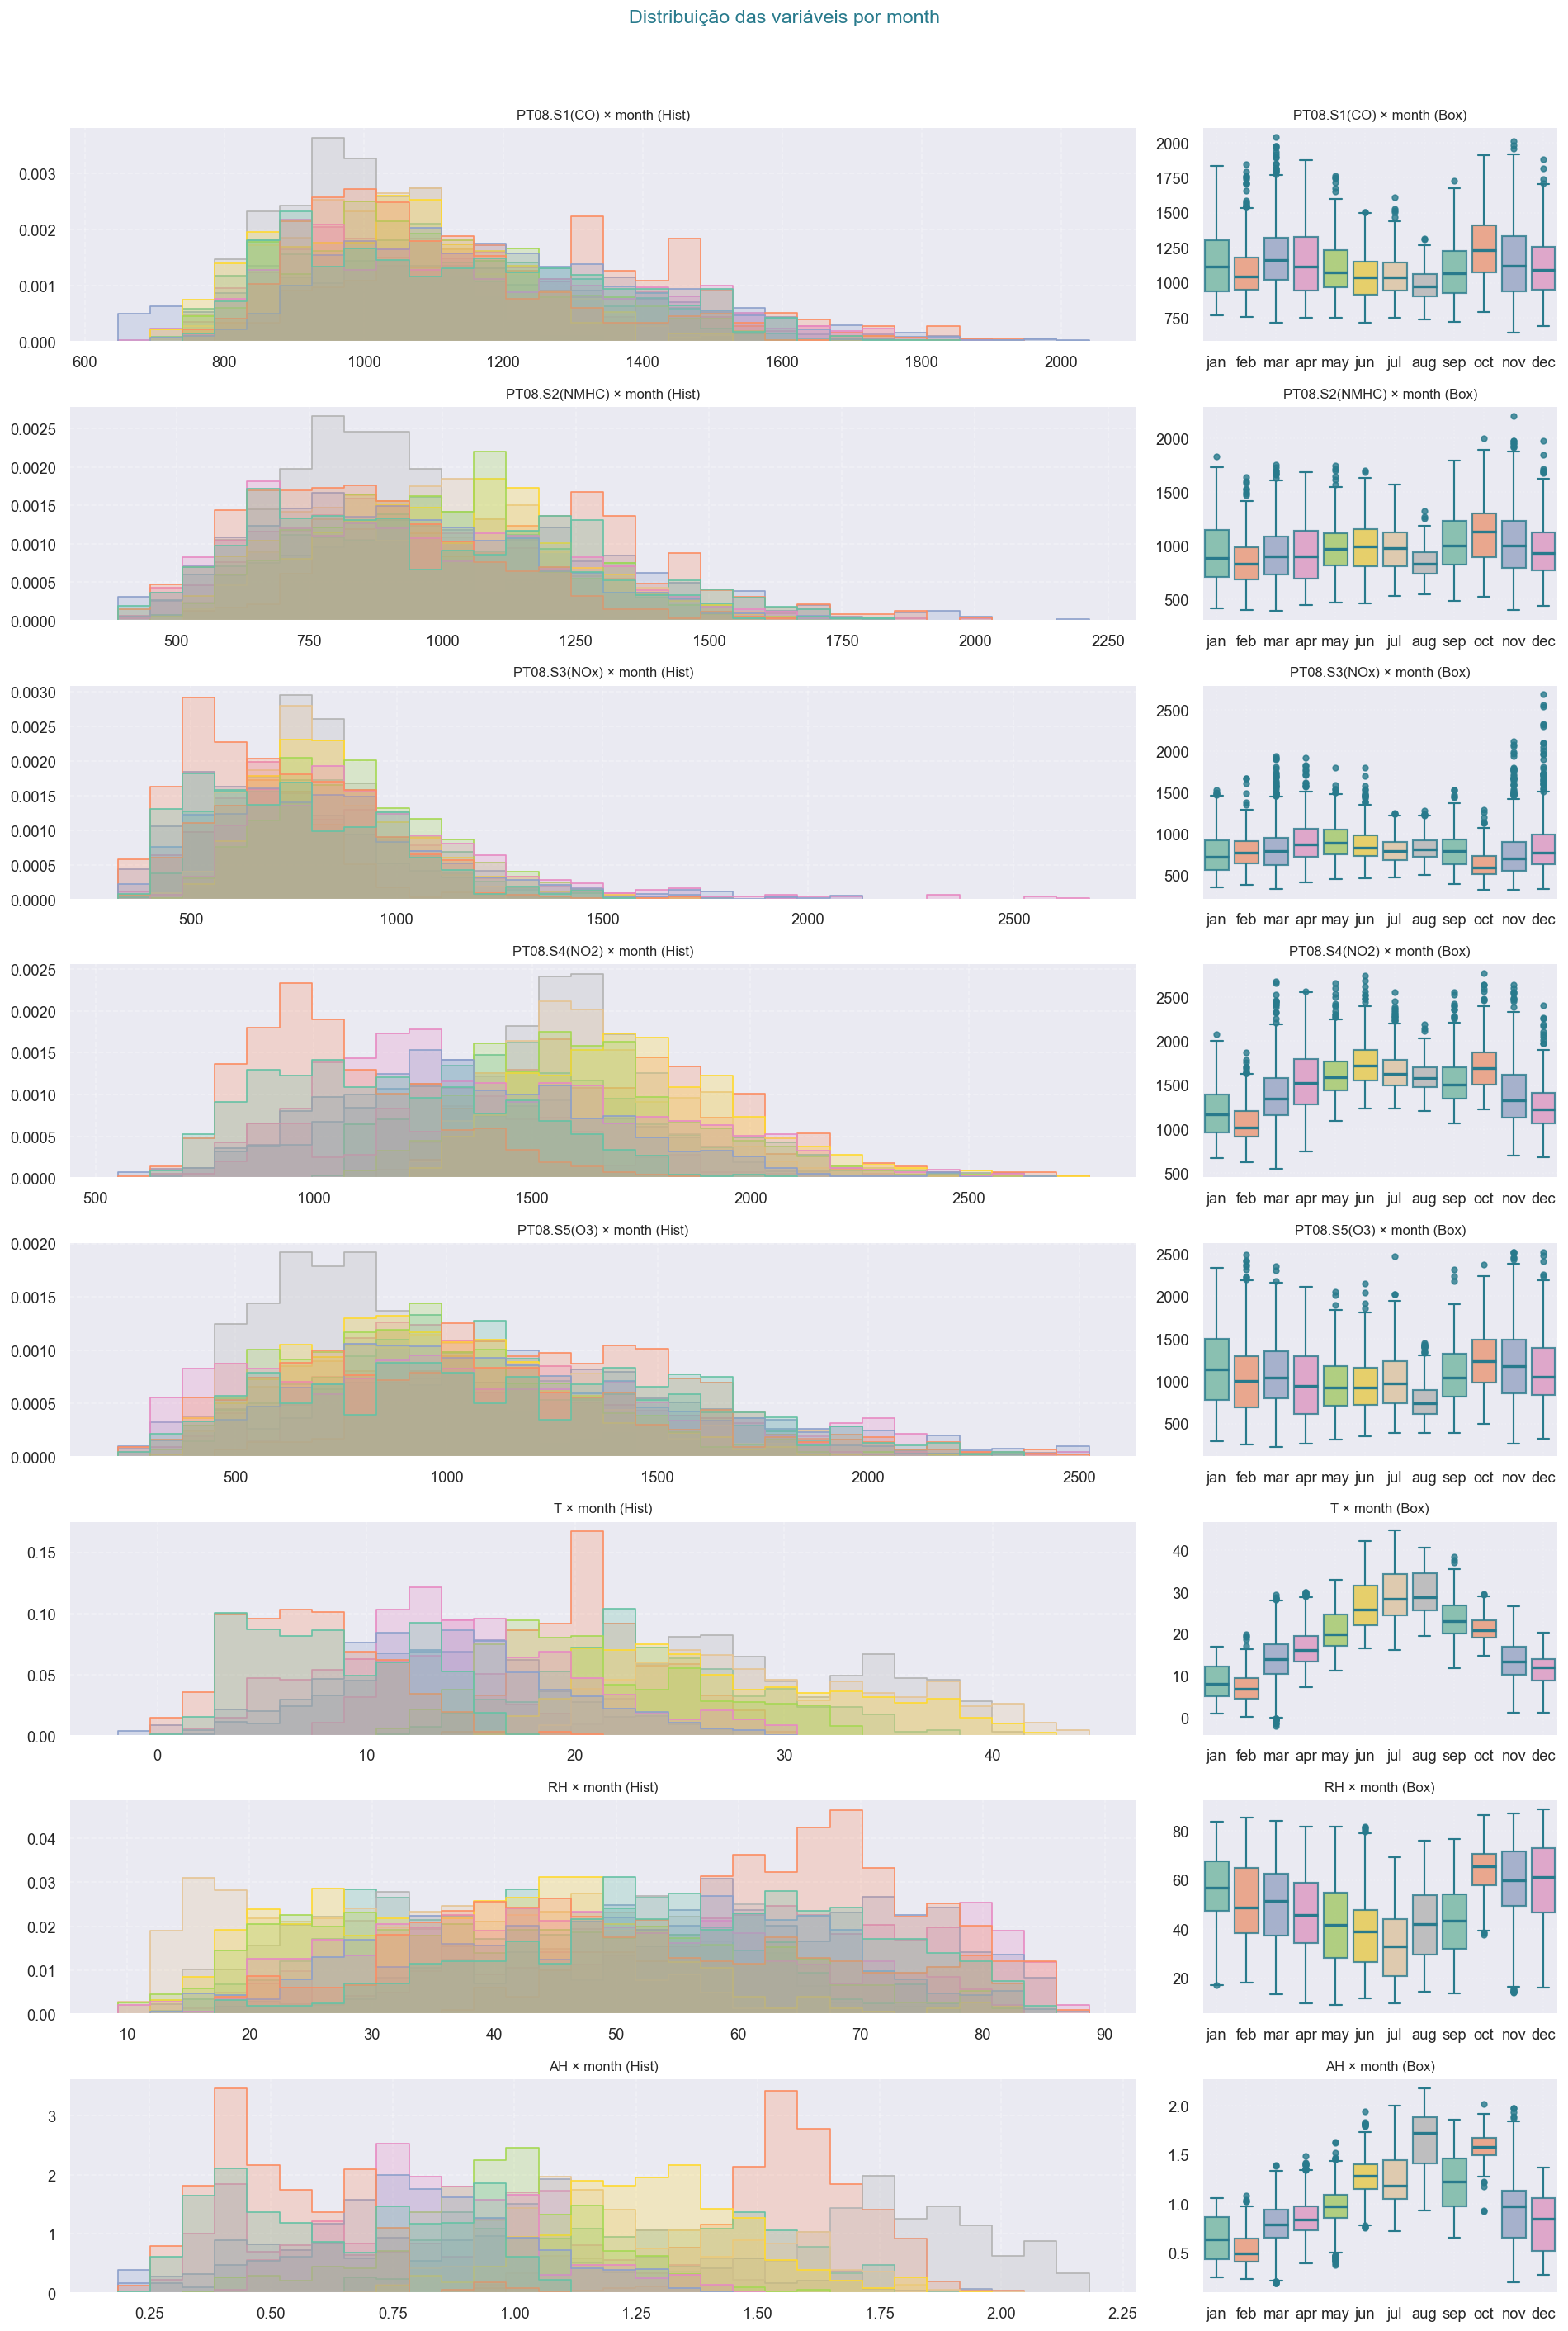


=== WEEKDAY ===



,PT08.S1(CO)_mean,PT08.S1(CO)_std,PT08.S1(CO)_skew,PT08.S2(NMHC)_mean,PT08.S2(NMHC)_std,PT08.S2(NMHC)_skew,PT08.S3(NOx)_mean,PT08.S3(NOx)_std,PT08.S3(NOx)_skew,PT08.S4(NO2)_mean,PT08.S4(NO2)_std,PT08.S4(NO2)_skew,PT08.S5(O3)_mean,PT08.S5(O3)_std,PT08.S5(O3)_skew,T_mean,T_std,T_skew,RH_mean,RH_std,RH_skew,AH_mean,AH_std,AH_skew
weekday,,,,,,,,,,,,,,,,,,,,,,,,
mon,1082.1408,213.1892,1.0026,942.6583,277.8886,0.6415,843.9049,260.6076,0.9484,1418.7087,359.4928,0.2439,1000.8194,423.4559,0.8419,17.4957,8.5033,0.4038,46.3690,16.8615,0.1480,0.9313,0.3991,0.3986
tue,1141.1914,232.9702,0.5919,1014.5462,300.0810,0.3002,792.2817,250.2977,0.8931,1507.9645,401.0243,0.1157,1125.7925,425.6327,0.4325,17.4442,8.8981,0.3163,47.9838,17.4999,0.0350,0.9562,0.3991,0.2318
wed,1157.4062,209.5867,0.6480,1018.6250,265.6189,0.3144,776.2478,246.2604,1.4353,1516.4429,363.2227,0.1918,1154.6832,381.7953,0.4525,17.9399,9.3870,0.3823,49.8996,18.0078,-0.1070,1.0092,0.4029,0.3899
thu,1171.7551,215.3312,0.6252,1017.2541,269.2604,0.3026,767.7869,246.1278,1.5642,1525.6926,355.7582,0.2113,1155.4969,383.5393,0.3478,18.0347,9.2631,0.4530,50.8162,17.1310,-0.0953,1.0369,0.4049,0.4401
fri,1174.2809,227.6767,0.4689,1030.8078,262.2002,0.1542,759.8675,250.7259,2.3212,1537.3127,347.5730,0.0078,1156.8217,403.1743,0.3979,18.2851,8.4910,0.3820,50.3959,17.8211,-0.1606,1.0319,0.3850,0.3306
sat,1102.6704,205.7392,0.6589,910.4638,189.9911,0.2490,823.4995,209.9993,0.5964,1388.5258,292.0433,-0.3084,1011.2394,375.9749,0.6433,17.6868,8.7235,0.3977,48.4783,17.2475,0.0399,0.9761,0.3955,0.2286
sun,1018.2312,179.2866,0.9934,789.7639,175.4874,0.6413,946.7867,247.1194,0.9078,1290.2599,273.0712,-0.0944,819.7688,326.1129,0.9074,17.4120,8.6690,0.4353,48.3869,17.1370,0.0445,0.9604,0.4102,0.5157


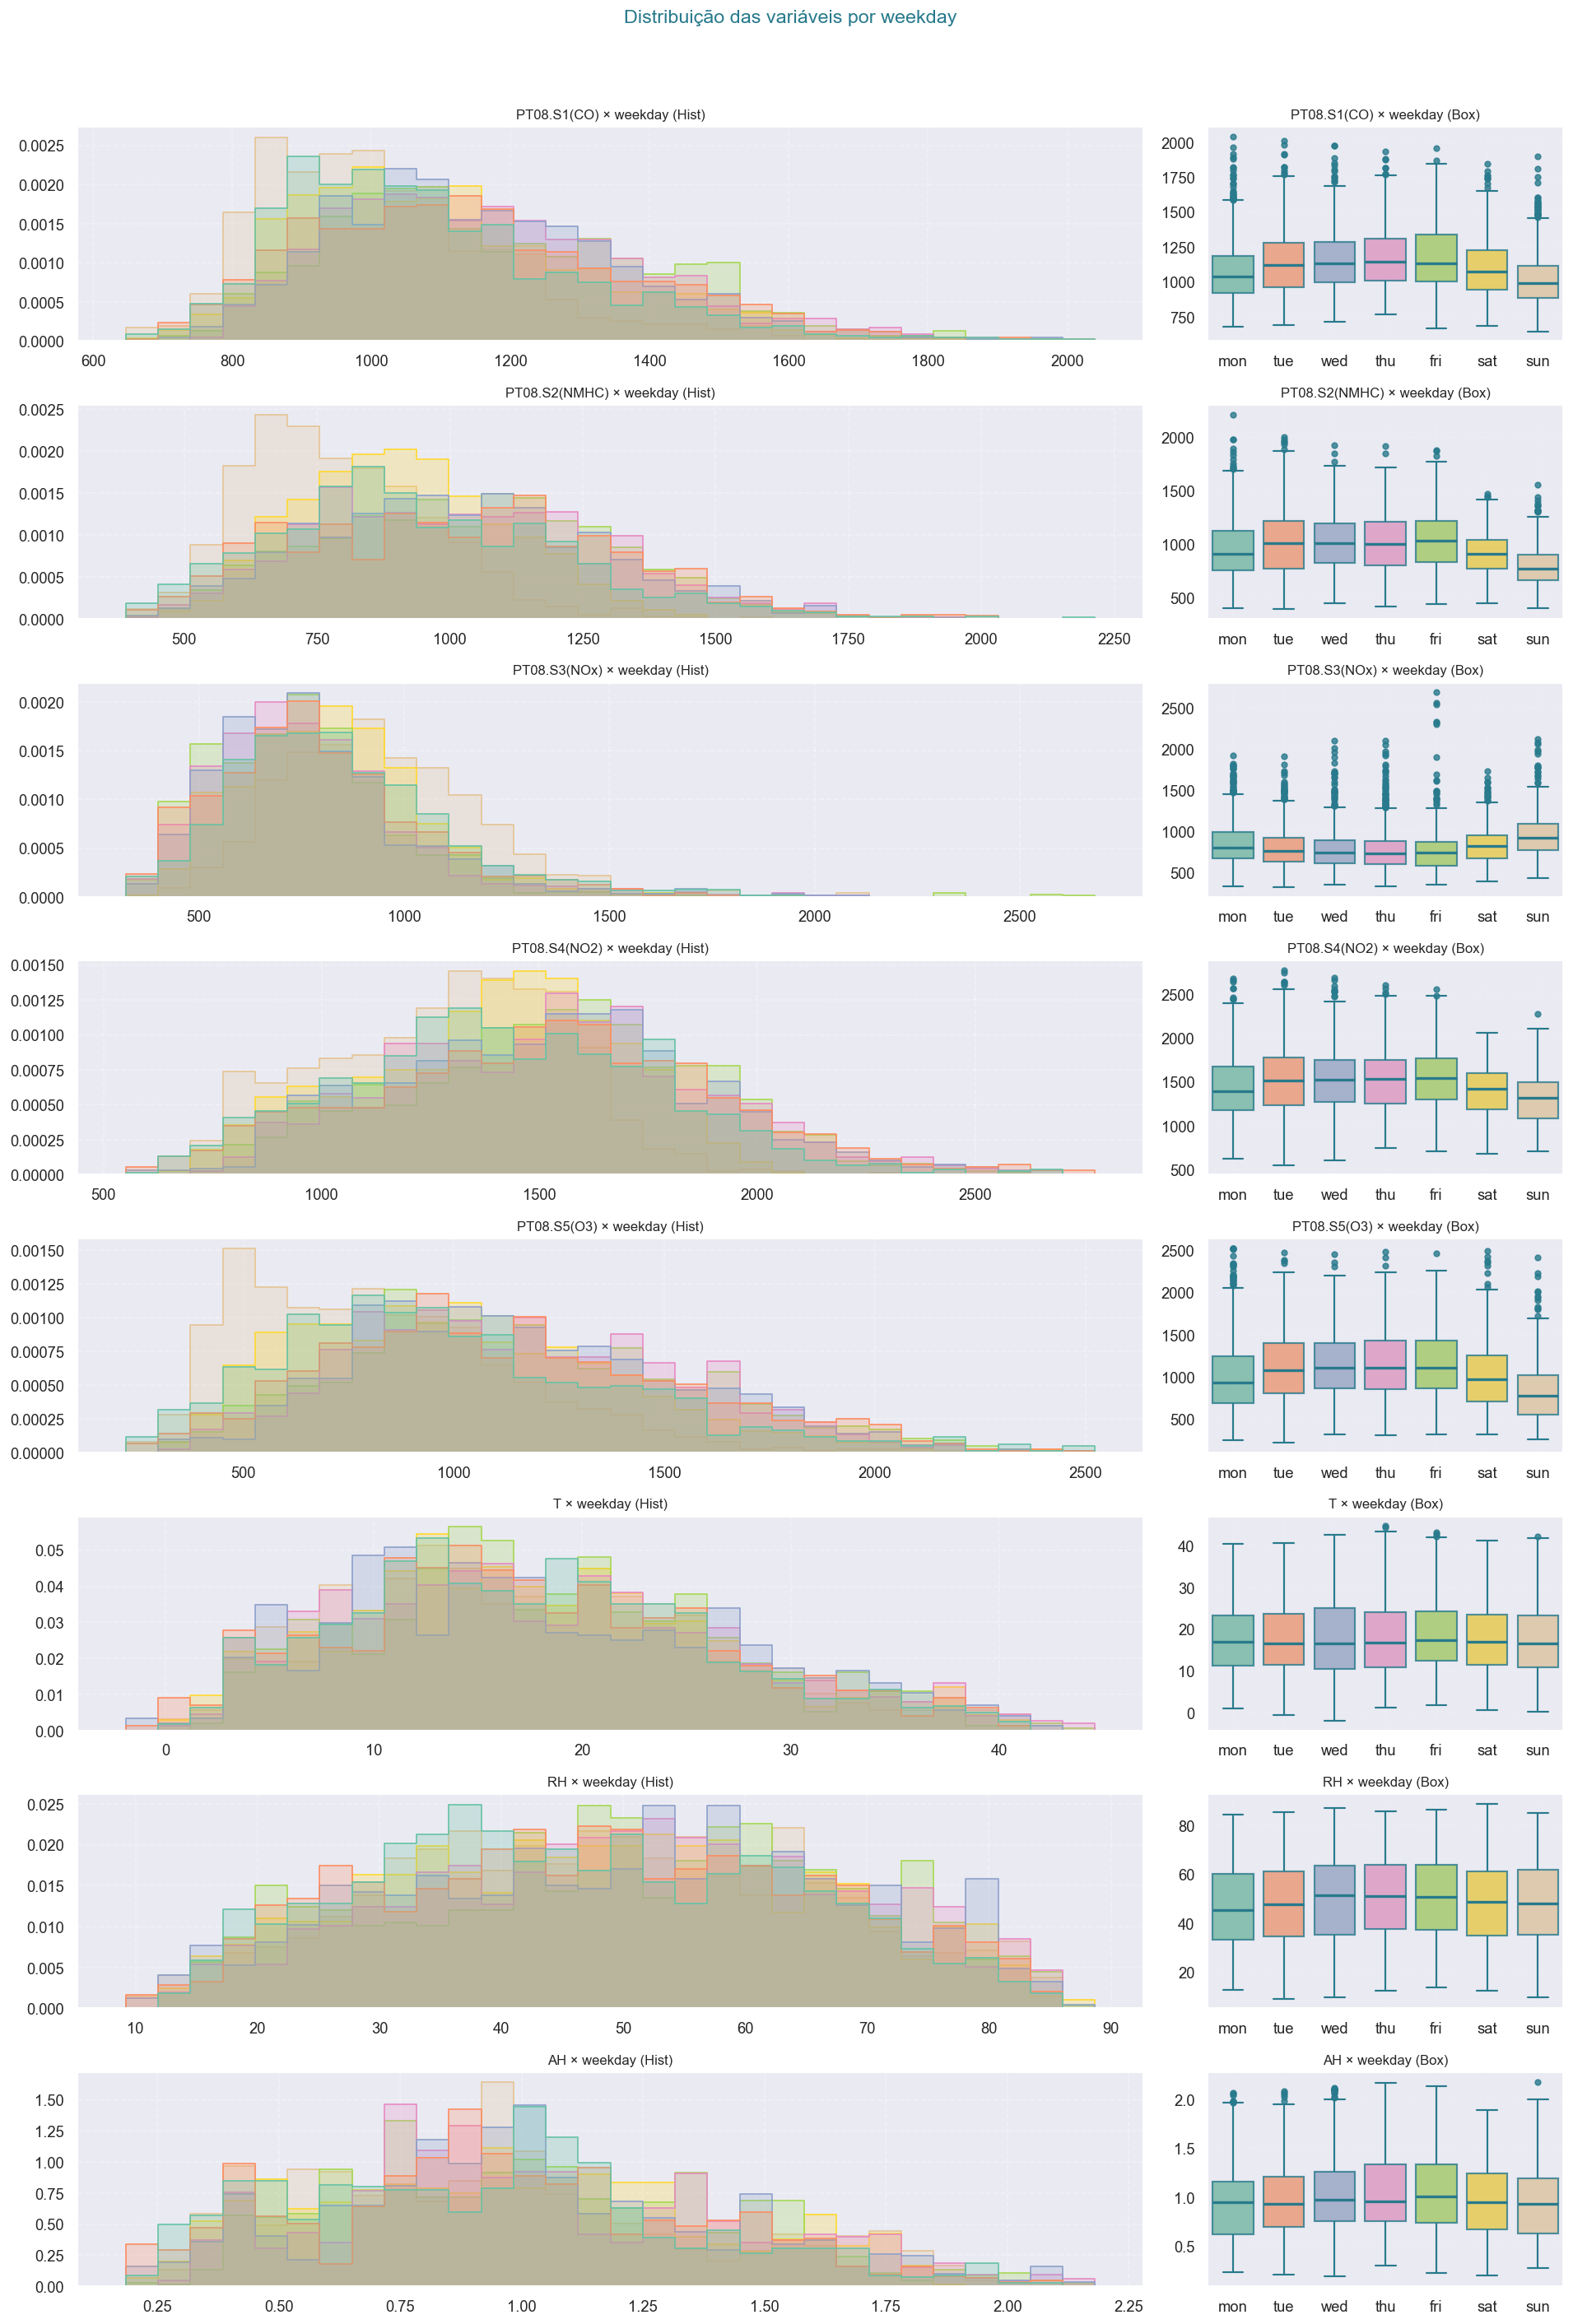


=== DAY_PERIOD ===



,PT08.S1(CO)_mean,PT08.S1(CO)_std,PT08.S1(CO)_skew,PT08.S2(NMHC)_mean,PT08.S2(NMHC)_std,PT08.S2(NMHC)_skew,PT08.S3(NOx)_mean,PT08.S3(NOx)_std,PT08.S3(NOx)_skew,PT08.S4(NO2)_mean,PT08.S4(NO2)_std,PT08.S4(NO2)_skew,PT08.S5(O3)_mean,PT08.S5(O3)_std,PT08.S5(O3)_skew,T_mean,T_std,T_skew,RH_mean,RH_std,RH_skew,AH_mean,AH_std,AH_skew
day_period,,,,,,,,,,,,,,,,,,,,,,,,
ngt,974.3899,152.0922,1.0291,741.6854,165.3000,0.6215,978.0859,262.5453,1.1151,1274.8871,264.9079,-0.1182,851.2621,311.0485,0.8484,14.5240,6.9938,0.0515,58.1477,13.3862,-0.0855,1.0071,0.4061,0.3512
mng,1139.6164,219.3831,0.4571,980.8416,277.8775,0.3244,799.8399,264.7041,1.5102,1495.7412,386.3932,0.2136,1121.8275,403.1474,0.2122,15.9321,8.2062,0.2534,53.5680,15.5483,-0.0968,0.9895,0.4015,0.4034
aft,1135.2868,203.1846,0.5185,999.7507,224.3902,0.3725,790.5535,213.4557,0.7868,1455.9897,327.7283,-0.0989,1017.3335,405.8711,0.6411,21.9627,9.7000,0.2508,37.4808,17.1207,0.6624,0.9491,0.3929,0.3758
eve,1195.7820,224.6532,0.7989,1060.4229,256.0109,0.6429,737.3705,208.5577,1.0384,1541.7345,354.5325,0.0978,1191.3856,405.9877,0.5355,17.8441,8.1752,0.2568,48.5070,15.9732,0.2115,1.0016,0.4028,0.2938


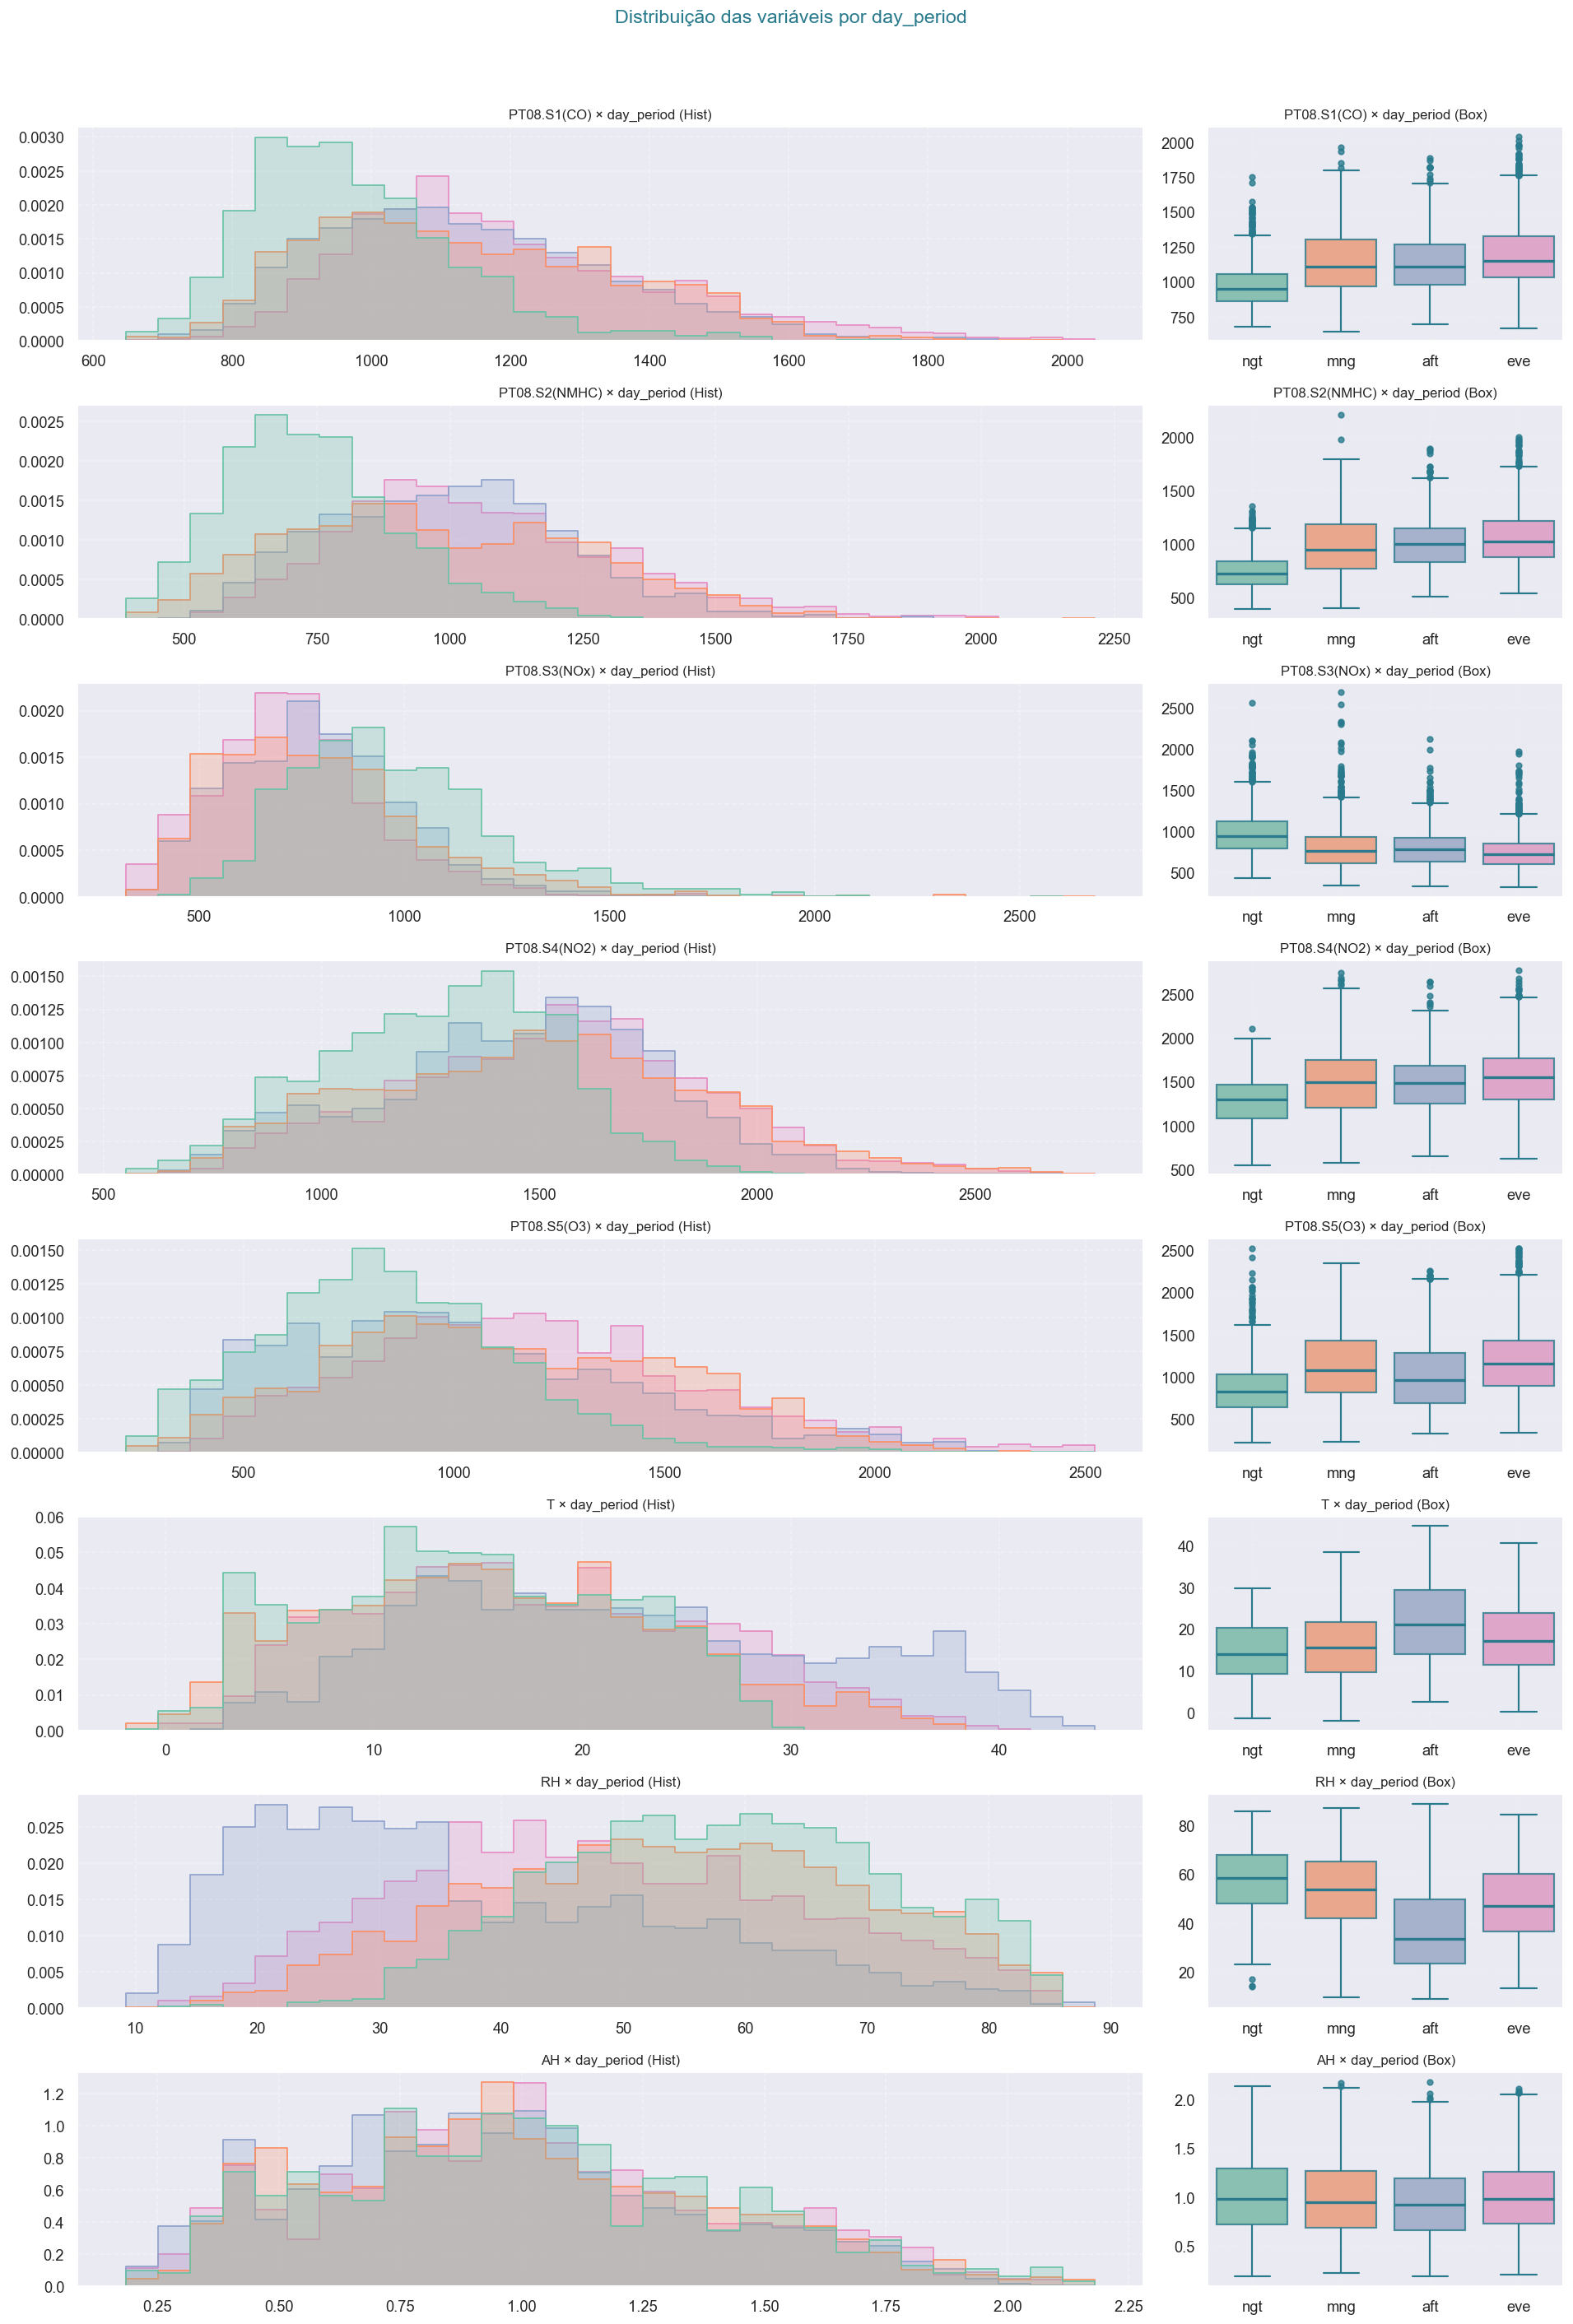

In [ ]:
# Paleta fixa "Paired"
paired_palette = sns.color_palette("Set2")

# Cores padrão do tema (mantidas)
fill, edge, outlier = palette[2], palette[3], palette[3]

predictors = ["PT08.S1(CO)", "PT08.S2(NMHC)", "PT08.S3(NOx)",
              "PT08.S4(NO2)", "PT08.S5(O3)", "T", "RH", "AH"]
temporal_classes = ["month", "weekday", "day_period"]

for cls in temporal_classes:
    print(f"\n=== {cls.upper()} ===\n")

    # Estatísticas descritivas por classe temporal
    stats_df = air_quality.groupby(cls)[predictors].agg(["mean", "std", "skew"])
    stats_df.columns = ["_".join(col) for col in stats_df.columns]
    display(stats_df.round(4))

    # Figura combinada (hist + box)
    fig, axes = plt.subplots(
        nrows=len(predictors),
        ncols=2,
        figsize=(16, len(predictors) * 3),
        dpi=plt.rcParams["figure.dpi"],
        gridspec_kw={"width_ratios": [3, 1]}
    )
    fig.suptitle(f"Distribuição das variáveis por {cls}", fontsize=14, color=edge)

    for i, col in enumerate(predictors):
        # --- HISTOGRAMA ---
        sns.histplot(
            data=air_quality, x=col, hue=cls,
            element="step", stat="density", common_norm=False,
            bins=30, ax=axes[i, 0], palette=paired_palette
        )
        axes[i, 0].set_title(f"{col} × {cls} (Hist)", fontsize=10)
        axes[i, 0].set_xlabel(""); axes[i, 0].set_ylabel("")
        axes[i, 0].grid(True, alpha=0.3, linestyle="--")

        # Remove a legenda (sem afetar as cores)
        axes[i, 0].legend_.remove() if axes[i, 0].get_legend() else None

        # --- BOX PLOT ---
        sns.boxplot(
            data=air_quality,
            x=cls, y=col,
            ax=axes[i, 1],
            linewidth=1.3,
            fliersize=3,
            palette=paired_palette,  # paleta fixa Paired
            boxprops=dict(edgecolor=edge, alpha=0.8),
            medianprops=dict(color=edge, linewidth=2),
            whiskerprops=dict(color=edge),
            capprops=dict(color=edge),
            flierprops=dict(
                marker="o",
                markerfacecolor=outlier,
                markeredgecolor=outlier,
                alpha=0.8,
                markersize=4
            ),
        )
        axes[i, 1].set_title(f"{col} × {cls} (Box)", fontsize=10)
        axes[i, 1].set_xlabel(""); axes[i, 1].set_ylabel("")
        axes[i, 1].grid(True, alpha=0.2, linestyle=":")

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    savefig(f"{cls}_distribution_boxplots")
    plt.show()


## 5.  Estátisticas bi-variadas incondicionais dos preditores.

##### 5.1 Definição de Preditores e Alvos
Separação conceitual das variáveis. Criamos dois DataFrames, air_quality_targets (com as medições reais de poluição e classes) e air_quality_predictors (com as leituras dos 5 sensores e as 3 variáveis climáticas).

In [ ]:
air_quality_targets = air_quality[
    [
        "CO(GT)",      # Monóxido de carbono (mg/m³)
        "NMHC(GT)",    # Hidrocarbonetos não metânicos (µg/m³)
        "C6H6(GT)",    # Benzeno (µg/m³)
        "NOx(GT)",     # Óxidos de nitrogênio totais (ppb)
        "NO2(GT)",      # Dióxido de nitrogênio (µg/m³)
        "pollution_class",
        "month",
        "weekday",
        "day_period"
    ]
]

air_quality_predictors = air_quality[
    [
        "PT08.S1(CO)",     # Sensor 1 — SnO₂ (CO)
        "PT08.S2(NMHC)",   # Sensor 2 — TiO₂ (NMHC)
        "PT08.S3(NOx)",    # Sensor 3 — WO₃ (NOx)
        "PT08.S4(NO2)",    # Sensor 4 — WO₃ (NO₂)
        "PT08.S5(O3)",     # Sensor 5 — In₂O₃ (O₃)
        "T",               # Temperatura (°C)
        "RH",              # Umidade relativa (%)
        "AH",              # Umidade absoluta (g/m³)
        "pollution_class",
        "month",
        "weekday",
        "day_period"
    ]
]

In [ ]:
air_quality_predictors.pollution_class.unique()

['Moderate', 'Low', 'High']
Categories (3, object): ['Low' < 'Moderate' < 'High']

##### 5.2 Pairplot (Gráfico de Pares) Condicional
Matriz de Scatter Plots. Criamos uma grade que plota cada preditor contra todos os outros. O objetivo é visualizar a separação das classes.

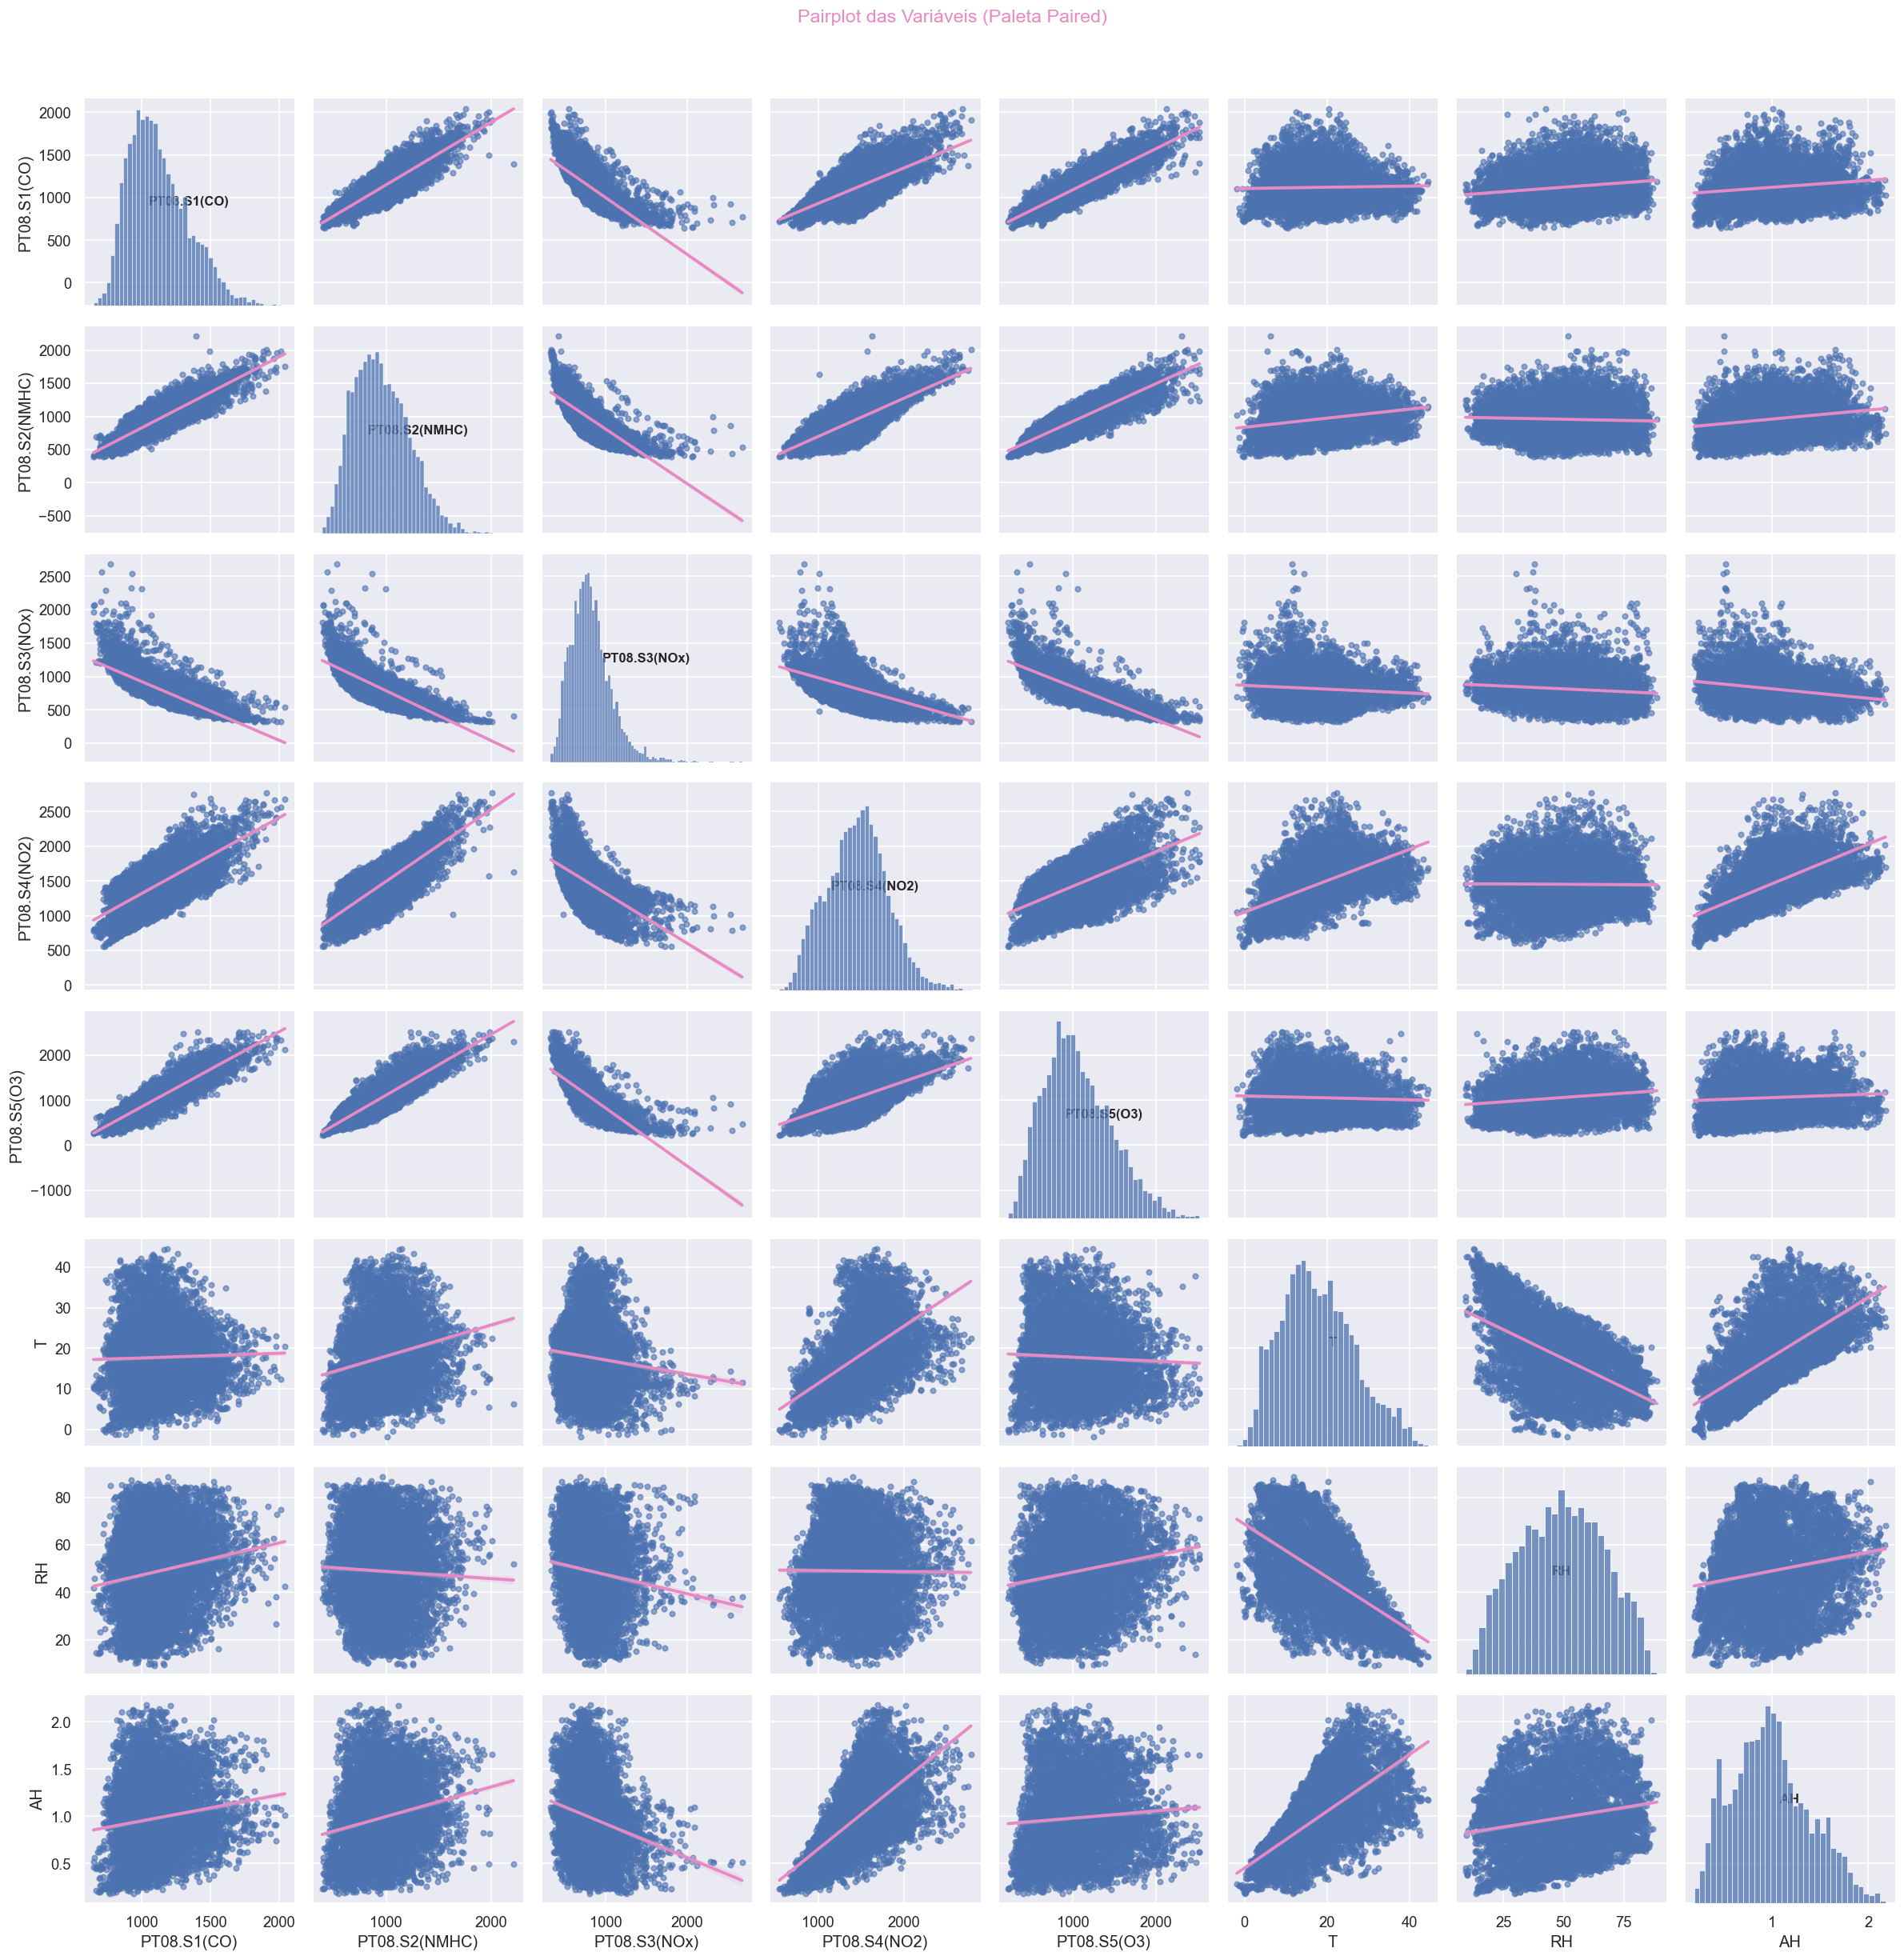

In [ ]:
# Pairplot com paleta aplicada
g = sns.pairplot(
    air_quality_predictors,
    kind="reg",
    diag_kind="hist",
    palette=paired_palette,  # usa a mesma paleta global
    plot_kws={"line_kws": {"color": paired_palette[3]}, "scatter_kws": {"alpha": 0.6, "s": 15}}
)

# Adiciona rótulos centrais nos gráficos diagonais
for i, var in enumerate(g.x_vars):
    ax = g.axes[i][i]
    ax.text(
        0.5, 0.5, var,
        fontsize=10, weight="bold",
        ha="center", va="center",
        transform=ax.transAxes
    )

# Ajustes visuais e exibição
plt.suptitle("Pairplot das Variáveis (Paleta Paired)", fontsize=14, color=paired_palette[3], y=1.02)
plt.tight_layout()
savefig("pairplot_paired")
plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Configuração visual padrão
sns.set(style="white", font_scale=0.9)

# Classes a analisar
categorical_classes = ["pollution_class", "weekday", "day_period"]

# Paleta única do projeto
paired_palette = sns.color_palette("Paired")

# Loop sobre as classes
for category in categorical_classes:
    print(f"\n=== Pairplot for: {category} ===")

    # Cria dataset temporário
    data = air_quality_predictors.copy()
    data[category] = air_quality[category]

    # Cria pairplot colorido pela classe, usando paleta "Paired"
    g = sns.pairplot(
        data,
        diag_kind="hist",
        hue=category,
        palette=paired_palette,
        plot_kws={"s": 10, "alpha": 0.25, "edgecolor": "none"}
    )

    # === Regressão global única (verde) ===
    for i, y_var in enumerate(g.y_vars):
        for j, x_var in enumerate(g.x_vars):
            if i != j:  # fora da diagonal
                ax = g.axes[i][j]
                x = data[x_var]
                y = data[y_var]

                # Remove NaN
                mask = ~(x.isna() | y.isna())
                x_clean, y_clean = x[mask], y[mask]

                # Ajuste polinomial global (linear)
                coeffs = np.polyfit(x_clean, y_clean, 1)
                poly = np.poly1d(coeffs)
                x_line = np.linspace(x_clean.min(), x_clean.max(), 200)
                y_line = poly(x_line)
                ax.plot(x_line, y_line, color="green", lw=1.5, zorder=5)

    # === Rótulos centralizados nos histogramas ===
    for i, var in enumerate(g.x_vars):
        ax = g.axes[i][i]
        ax.text(
            0.5, 0.5, var,
            fontsize=10, weight="bold",
            ha="center", va="center",
            transform=ax.transAxes,
            zorder=10,
            bbox=dict(facecolor="white", alpha=0.8, edgecolor="none")
        )

    # === Legenda e título ===
    if g._legend:
        g._legend.set_title(category)
        for text in g._legend.texts:
            text.set_fontsize(8)

    plt.suptitle(
        f"Pairwise Scatter Plots Colored by {category}\n(Global Linear Regression)",
        y=0.97,
        color=paired_palette[3],
        fontsize=18
    )

    plt.tight_layout()
    savefig(f"pairplot_{category}_paired")
    plt.show()



=== Pairplot for: pollution_class ===


NameError: name 'air_quality_predictors' is not defined

In [34]:
air_quality_predictors

,PT08.S1(CO),PT08.S2(NMHC),PT08.S3(NOx),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,pollution_class,month,weekday,day_period
datetime,,,,,,,,,,,,
2004-03-10 18:00:00,1360.0,1046.0,1056.0,1692.0,1268.0,13.6,48.9,0.7578,Moderate,mar,wed,eve
2004-03-10 19:00:00,1292.0,955.0,1174.0,1559.0,972.0,13.3,47.7,0.7255,Moderate,mar,wed,eve
2004-03-10 20:00:00,1402.0,939.0,1140.0,1555.0,1074.0,11.9,54.0,0.7502,Moderate,mar,wed,eve
2004-03-10 21:00:00,1376.0,948.0,1092.0,1584.0,1203.0,11.0,60.0,0.7867,Moderate,mar,wed,eve
2004-03-10 22:00:00,1272.0,836.0,1205.0,1490.0,1110.0,11.2,59.6,0.7888,Moderate,mar,wed,eve
...,...,...,...,...,...,...,...,...,...,...,...,...
2005-04-04 10:00:00,1314.0,1101.0,539.0,1374.0,1729.0,21.9,29.3,0.7568,High,apr,mon,mng
2005-04-04 11:00:00,1163.0,1027.0,604.0,1264.0,1269.0,24.3,23.7,0.7119,High,apr,mon,mng
2005-04-04 12:00:00,1142.0,1063.0,603.0,1241.0,1092.0,26.9,18.3,0.6406,High,apr,mon,aft


##### 5.3 Matriz de Correlação
Matriz de Correlação de Pearson e Heatmap. Calculamos o coeficiente de correlação para cada par de preditores e o visualizamos como um mapa de calor. 

In [35]:
numeric_predictors = air_quality_predictors.select_dtypes(include='number')
predictors_corr = numeric_predictors.corr(method="pearson")

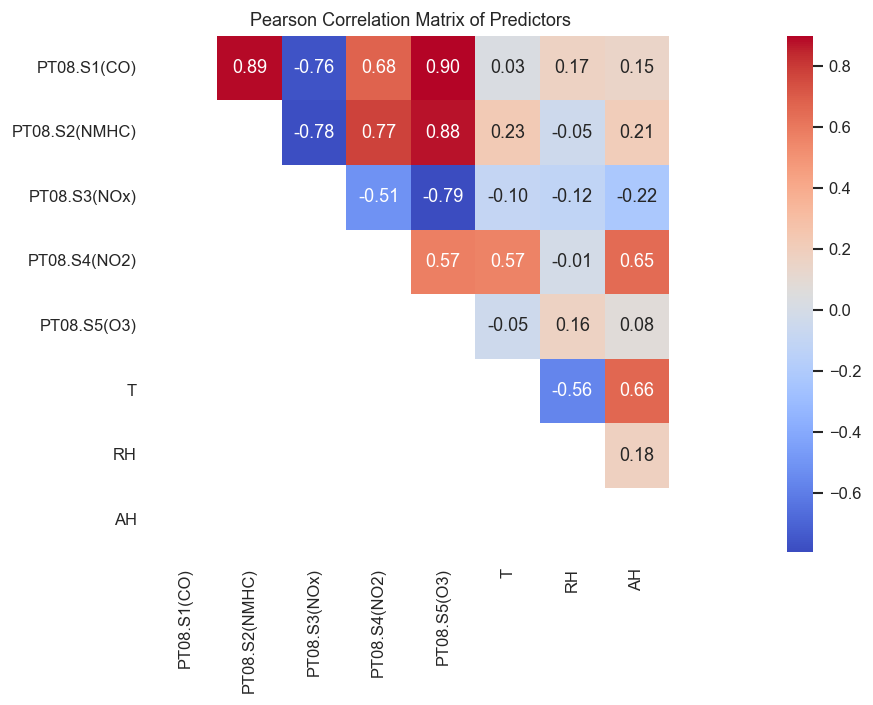

In [36]:
mask = np.tril(np.ones_like(predictors_corr, dtype=bool))
sns.heatmap(predictors_corr, annot=True, fmt=".2f", cmap="coolwarm", square=True, mask=mask)
plt.title("Pearson Correlation Matrix of Predictors")
plt.tight_layout()
savefig("predictors_correlation_matrix")
plt.show()

##### 5.4 Contagem de Outliers 
Usamos o Z-score para contar quantos valores em cada coluna são considerados extremos (mais de 3 desvios padrão da média).

In [37]:
from scipy import stats  
print("Outlier count per variable (|z| > 3):")
numeric_df = air_quality.select_dtypes(include=np.number)
outlier_counts = (
    numeric_df.apply(lambda x: (np.abs(stats.zscore(x, nan_policy='omit')) > 3).sum())
    .sort_values(ascending=False)
)
outlier_counts

Outlier count per variable (|z| > 3):


NOx(GT)_z          118
NOx(GT)            118
CO(GT)_z            87
CO(GT)              87
PT08.S3(NOx)        87
C6H6(GT)            85
C6H6(GT)_z          85
pollution_index     71
PT08.S1(CO)         41
NO2(GT)             36
NO2(GT)_z           36
PT08.S5(O3)         27
PT08.S2(NMHC)       27
PT08.S4(NO2)        27
NMHC(GT)             9
T                    2
AH                   0
RH                   0
dtype: int64

## 6. Análise de Componentes Principais (PCA)

##### 6.1 Seleção e Padronização dos Dados

In [38]:
numeric_predictors

,PT08.S1(CO),PT08.S2(NMHC),PT08.S3(NOx),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
datetime,,,,,,,,
2004-03-10 18:00:00,1360.0,1046.0,1056.0,1692.0,1268.0,13.6,48.9,0.7578
2004-03-10 19:00:00,1292.0,955.0,1174.0,1559.0,972.0,13.3,47.7,0.7255
2004-03-10 20:00:00,1402.0,939.0,1140.0,1555.0,1074.0,11.9,54.0,0.7502
2004-03-10 21:00:00,1376.0,948.0,1092.0,1584.0,1203.0,11.0,60.0,0.7867
2004-03-10 22:00:00,1272.0,836.0,1205.0,1490.0,1110.0,11.2,59.6,0.7888
...,...,...,...,...,...,...,...,...
2005-04-04 10:00:00,1314.0,1101.0,539.0,1374.0,1729.0,21.9,29.3,0.7568
2005-04-04 11:00:00,1163.0,1027.0,604.0,1264.0,1269.0,24.3,23.7,0.7119
2005-04-04 12:00:00,1142.0,1063.0,603.0,1241.0,1092.0,26.9,18.3,0.6406


In [39]:
# Pega os valores numéricos como matriz NumPy
X = numeric_predictors.values
print("Matriz de dados (primeiras 5 linhas):\n", X[:5])

Matriz de dados (primeiras 5 linhas):
 [[1.360e+03 1.046e+03 1.056e+03 1.692e+03 1.268e+03 1.360e+01 4.890e+01
  7.578e-01]
 [1.292e+03 9.550e+02 1.174e+03 1.559e+03 9.720e+02 1.330e+01 4.770e+01
  7.255e-01]
 [1.402e+03 9.390e+02 1.140e+03 1.555e+03 1.074e+03 1.190e+01 5.400e+01
  7.502e-01]
 [1.376e+03 9.480e+02 1.092e+03 1.584e+03 1.203e+03 1.100e+01 6.000e+01
  7.867e-01]
 [1.272e+03 8.360e+02 1.205e+03 1.490e+03 1.110e+03 1.120e+01 5.960e+01
  7.888e-01]]


In [40]:
# Padroniza os dados (média 0, desvio padrão 1)
X_std = (X - np.mean(X, axis=0)) / np.std(X, axis=0)
print("Dados padronizados (primeiras 5 linhas):\n", X_std[:5])

Dados padronizados (primeiras 5 linhas):
 [[ 1.09769994e+00  3.31231353e-01  9.49291374e-01  6.77518478e-01
   5.17228727e-01 -4.69832174e-01  1.03805876e-03 -5.67915907e-01]
 [ 7.86797309e-01 -1.34186460e-02  1.41777019e+00  3.01042428e-01
  -2.10973178e-01 -5.03752434e-01 -6.78011052e-02 -6.48450934e-01]
 [ 1.28972803e+00 -7.40164479e-02  1.28278477e+00  2.89719840e-01
   3.99612623e-02 -6.62046982e-01  2.93604506e-01 -5.86865325e-01]
 [ 1.17085350e+00 -3.99301843e-02  1.09221711e+00  3.71808603e-01
   3.57319525e-01 -7.63807763e-01  6.37800325e-01 -4.95858252e-01]
 [ 6.95355359e-01 -4.64114798e-01  1.54084513e+00  1.05727785e-01
   1.28526359e-01 -7.41194256e-01  6.14853937e-01 -4.90622228e-01]]


##### 6.2 Cálculo da Matriz de Covariância
A matriz de covariância mede como cada variável muda em relação a todas as outras.

In [41]:
# Calcula a matriz de covariância
cov_matrix = np.cov(X_std.T)
print("Matriz de Covariância:\n", cov_matrix)

Matriz de Covariância:
 [[ 1.00014409  0.88619598 -0.76300444  0.67600699  0.89729563  0.02828084
   0.16925846  0.14977397]
 [ 0.88619598  1.00014409 -0.78174292  0.77439911  0.87690361  0.22836598
  -0.04609038  0.2056199 ]
 [-0.76300444 -0.78174292  1.00014409 -0.51129711 -0.79347843 -0.09950917
  -0.11649625 -0.22341318]
 [ 0.67600699  0.77439911 -0.51129711  1.00014409  0.57432475  0.5666672
  -0.0091614   0.64648327]
 [ 0.89729563  0.87690361 -0.79347843  0.57432475  1.00014409 -0.04615266
   0.16484496  0.07581786]
 [ 0.02828084  0.22836598 -0.09950917  0.5666672  -0.04615266  1.00014409
  -0.56399017  0.66073325]
 [ 0.16925846 -0.04609038 -0.11649625 -0.0091614   0.16484496 -0.56399017
   1.00014409  0.17960179]
 [ 0.14977397  0.2056199  -0.22341318  0.64648327  0.07581786  0.66073325
   0.17960179  1.00014409]]


##### 6.3 Autovalores e Autovetores
Decomposição da Matriz de Covariância.

In [42]:
# Determina os autovalores e autovetores
eig_vals, eig_vecs = np.linalg.eig(cov_matrix)
print("Autovalores:\n", eig_vals)
print("\nAutovetores:\n", eig_vecs)

Autovalores:
 [4.21704367 1.98356586 1.16650916 0.35575214 0.0934603  0.10870409
 0.0360261  0.04009142]

Autovetores:
 [[-0.44387906 -0.20143241  0.06424433  0.22822907 -0.82344387 -0.11931806
  -0.09729159  0.06647   ]
 [-0.46178134 -0.05663285  0.19293596  0.1700033   0.36486069  0.27352337
  -0.20642297  0.68328362]
 [ 0.4094496   0.14993264 -0.05967322  0.80455508  0.03468244 -0.33545574
  -0.0772262   0.19825275]
 [-0.41399563  0.26752501 -0.1418565   0.46721363  0.15517788  0.42296177
   0.1320618  -0.54608516]
 [-0.42916369 -0.26101558  0.11453818  0.02727439  0.38197275 -0.72034102
   0.13424667 -0.22585387]
 [-0.15173343  0.66057066  0.09305508 -0.11954292 -0.12985008 -0.18114001
   0.62175043  0.28535462]
 [-0.03723228 -0.39243348 -0.76241647  0.04579024  0.02636022  0.06662962
   0.44551079  0.2400414 ]
 [-0.2051762   0.45131088 -0.5761138  -0.19047775  0.0086447  -0.251751
  -0.56696037  0.03368941]]


#### 6.4 Ordenação dos autovalores
Ordenamos os autovalores (e seus autovetores correspondentes) do maior para o menor. Utilizamos afim de identificar o Componente Principal 1 como o eixo mais importante e o PC2 como o segundo mais importante.

In [43]:
sort_indices = np.argsort(eig_vals)[::-1]
sorted_eig_vals = eig_vals[sort_indices]
sorted_eig_vecs = eig_vecs[:, sort_indices]

print("Autovalores ordenados:\n", sorted_eig_vals)
print("Autovetores ordenados:\n", sorted_eig_vecs)

Autovalores ordenados:
 [4.21704367 1.98356586 1.16650916 0.35575214 0.10870409 0.0934603
 0.04009142 0.0360261 ]
Autovetores ordenados:
 [[-0.44387906 -0.20143241  0.06424433  0.22822907 -0.11931806 -0.82344387
   0.06647    -0.09729159]
 [-0.46178134 -0.05663285  0.19293596  0.1700033   0.27352337  0.36486069
   0.68328362 -0.20642297]
 [ 0.4094496   0.14993264 -0.05967322  0.80455508 -0.33545574  0.03468244
   0.19825275 -0.0772262 ]
 [-0.41399563  0.26752501 -0.1418565   0.46721363  0.42296177  0.15517788
  -0.54608516  0.1320618 ]
 [-0.42916369 -0.26101558  0.11453818  0.02727439 -0.72034102  0.38197275
  -0.22585387  0.13424667]
 [-0.15173343  0.66057066  0.09305508 -0.11954292 -0.18114001 -0.12985008
   0.28535462  0.62175043]
 [-0.03723228 -0.39243348 -0.76241647  0.04579024  0.06662962  0.02636022
   0.2400414   0.44551079]
 [-0.2051762   0.45131088 -0.5761138  -0.19047775 -0.251751    0.0086447
   0.03368941 -0.56696037]]


#### 6.5 Variância explicada por cada componente
Calculamos o percentual da informação total (variância) que cada Componente Principal captura. A saída aqui nos mostra que PC1 + PC2 capturam a grande maioria da variância total, provando que nosso gráfico final do PCA estará correto.

In [44]:
total_variance = np.sum(sorted_eig_vals)
explained_variance_ratio = sorted_eig_vals / total_variance
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

print("Variância explicada por cada componente:\n", explained_variance_ratio)
print("Variância explicada acumulada:\n", cumulative_explained_variance)

Variância explicada por cada componente:
 [0.52705451 0.24791001 0.14579264 0.04446261 0.01358605 0.01168085
 0.0050107  0.00450261]
Variância explicada acumulada:
 [0.52705451 0.77496453 0.92075716 0.96521977 0.97880583 0.99048668
 0.99549739 1.        ]


#### 6.6 Projeção dos dados
Pegamos os 2 primeiros autovetores (W) e os usamos para transformar (via multiplicação de matrizes) nossos dados padronizados de 8 dimensões (X_std) em novos dados de 2 dimensões (X_pca).

In [45]:
W = sorted_eig_vecs[:, :2]  # Seleciona os dois primeiros autovetores. 8 preditores serão reduzidos para 2 componentes principais
X_pca = X_std.dot(W)
print(f"Formato dos dados originais (padronizados): {X_std.shape}")
print(f"Formato da matriz de projeção (W): {W.shape}")
print(f"Formato dos dados transformados (PCA): {X_pca.shape}")


Formato dos dados originais (padronizados): (6941, 8)
Formato da matriz de projeção (W): (8, 2)
Formato dos dados transformados (PCA): (6941, 2)


## 7. Gerar gráfico PCA

#### 7.1 Preparação de Dataframe para plotagem
Colocamos nossa matriz NumPy X_pca em um DataFrame do pandas e concatenamos com a coluna pollution_class.

In [51]:
pca_df = pd.DataFrame(
    data = X_pca,
    columns = ['PC1', 'PC2'],
    index=numeric_predictors.index
)

final_pca_df = pd.concat([pca_df, air_quality_targets[['pollution_class']]], axis=1)

print("DataFrame final para plotagem (primeiras 5 linhas):")
display(final_pca_df.head())

DataFrame final para plotagem (primeiras 5 linhas):


,PC1,PC2,pollution_class
datetime,,,
2004-03-10 18:00:00,-0.566208,-0.618364,Moderate
2004-03-10 19:00:00,0.415378,-0.408362,Moderate
2004-03-10 20:00:00,0.059773,-0.813601,Moderate
2004-03-10 21:00:00,-0.167459,-1.042255,Moderate
2004-03-10 22:00:00,0.627870,-0.840346,Moderate


#### 7.2 Gerando o gráfico PCA final
Este é o gráfico resultado do PCA. Nos permite visualizar todas observações em um único gráfico 2D e confirmar se as classes de poluição formam grupos distintos. No gráfico, há uma separação clara ao longo do eixo PC1, provando que o PCA conseguiu capturar o "nível de poluição geral" como o principal componente de variação nos dados.

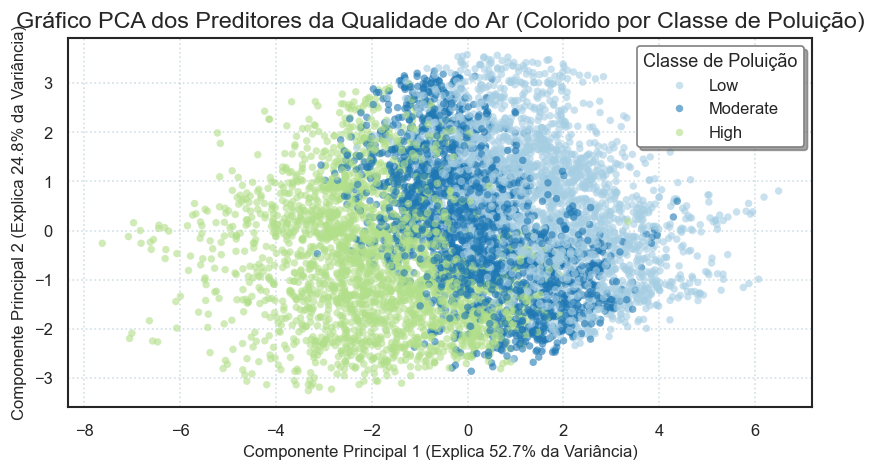

In [54]:
#Tamanho da figura e scatter plot principal
plt.figure(figsize=(8, 4), dpi=plt.rcParams["figure.dpi"])

ax = sns.scatterplot(
    data=final_pca_df,
    x='PC1',
    y='PC2',
    hue='pollution_class',
    palette=paired_palette,
    s = 20,
    alpha=0.6,
    edgecolor='none'
)

#Titutlos e gráficos
ax.set_title("Gráfico PCA dos Preditores da Qualidade do Ar (Colorido por Classe de Poluição)", fontsize=14)
ax.set_xlabel(f"Componente Principal 1 (Explica {explained_variance_ratio[0]:.1%} da Variância)", fontsize=10)
ax.set_ylabel(f"Componente Principal 2 (Explica {explained_variance_ratio[1]:.1%} da Variância)", fontsize=10)

#Legenda
leg = ax.legend(title='Classe de Poluição', loc='best', frameon=True, shadow=True)
leg.get_frame().set_facecolor('white')
leg.get_frame().set_edgecolor('gray')

#Grid, salvamento e exibição
ax.grid(True, color=palette[4], alpha=0.2, linestyle=":")

savefig("pca_2d_scatterplot_by_class")

plt.show()